# Modelamiento termo-fluido de un intercooler aire-aire acoplado a un motor diésel

Juan Carlos Muñoz

Samuel Gustavo Pedraza

---

In [1]:
from IPython.display import Image, display

def mostrar_imagen(ruta, ancho=600):
    display(Image(filename=ruta, width=ancho))



# 1. Contexto y justificación

## 1.1 Contexto del proyecto

El proyecto de curso parte del modelamiento numérico de un motor de ciclo diésel, en el cual se ha analizado el comportamiento de diferentes combustibles:  ACPM B10 y biodiésel de primera generación. En etapas anteriores se estudiaron variables como el poder calorífico, el requerimiento de aire, los productos de combustión y el desempeño energético de cada combustible.

Posteriormente, el modelo fue complementado con un compresor centrífugo ubicado en el sistema de admisión. Este dispositivo permite aumentar la presión del aire antes de su ingreso al motor, favoreciendo la disponibilidad de oxígeno para la combustión. Sin embargo, el proceso de compresión también incrementa la temperatura del aire, lo cual puede afectar las condiciones finales de admisión.

Por esta razón, se incorpora un intercooler aire-aire, el cual sera modelado como in intercambiador de calor de flujo cruzado, entre la salida del compresor y la entrada del motor. Su función es enfriar el aire comprimido antes de que ingrese al cilindro, permitiendo evaluar de forma más completa el sistema de admisión del motor diésel.


La incorporación del intercooler se justifica porque el aire que sale del compresor presenta una temperatura elevada. Aunque el aumento de presión es beneficioso para la admisión, el aumento de temperatura puede reducir parte de ese beneficio al modificar las condiciones termodinámicas con las que el aire entra al motor.

El intercooler permite retirar parte del calor del aire comprimido mediante un proceso de transferencia de calor con el ambiente. En este proyecto, se modela como un intercambiador de calor compacto aire-aire de flujo cruzado, usando el número de pasos como parámetro principal de diseño.


---



# 2. Descripción física del sistema

## 2.1 Configuración general del sistema motor-compresor-intercooler

A continuación se muestra un diagrama sobre el sistema. Este está compuesto por el motor diésel, el compresor centrífugo previamente modelado y el intercooler aire-aire incorporado como dispositivo térmico adicional.




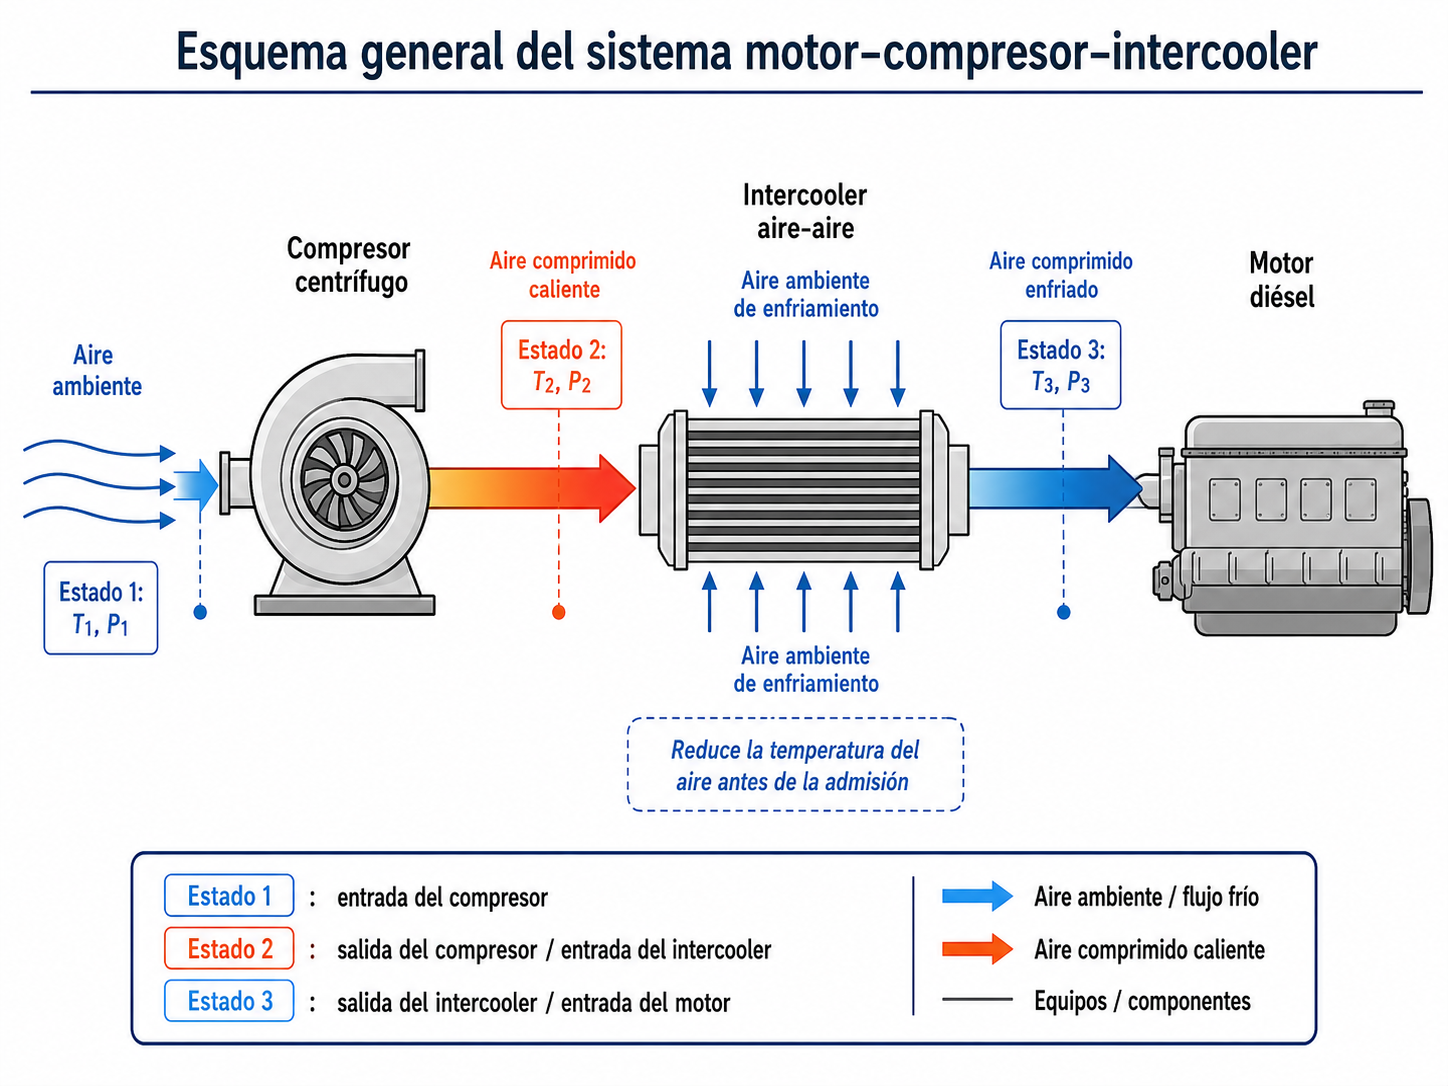

In [ ]:
mostrar_imagen("DIAGRAMA.png")




## 2.2 Ubicación del intercooler en el sistema de admisión

Como se pudo ver en la imagen anterior, el intercooler se ubica justo después del compresor centrífugo y antes de la admisión del motor. Su función principal es disminuir la temperatura del aire comprimido que sale del compresor antes de que ingrese al cilindro.

Esta ubicación permite acondicionar térmicamente el aire de admisión, ya que el proceso de compresión aumenta la presión del aire, pero también eleva su temperatura. Por tanto, el intercooler actúa como una etapa intermedia de enfriamiento entre la compresión y la entrada al motor.

La secuencia física del sistema es:

Aire ambiente  
↓  
Compresor centrífugo  
↓  
Aire comprimido caliente  
↓  
Intercooler aire-aire  
↓  
Aire comprimido enfriado  
↓  
Admisión del motor diésel  

---

## 2.3 Tipo de intercambiador y corrientes de flujo

Para el presente modelo, el intercooler se aproxima como un intercambiador de calor aire-aire de flujo cruzado. Esta configuración representa mejor el funcionamiento de un intercooler, ya que el aire comprimido circula por conductos internos mientras el aire ambiente atraviesa externamente el núcleo del intercambiador.

La corriente caliente corresponde al aire comprimido proveniente de la salida del compresor. Esta corriente entra al intercooler con una temperatura elevada y debe ser enfriada antes de ingresar al motor.

Por otra parte, la corriente fría corresponde al aire ambiente utilizado como medio de enfriamiento. Esta corriente absorbe parte del calor retirado del aire comprimido y permite reducir la temperatura final de admisión.

| Corriente | Fluido | Ubicación | Función |
|---|---|---|---|
| Corriente caliente | Aire comprimido | Salida del compresor | Ceder calor |
| Corriente fría | Aire ambiente | Exterior del intercooler | Absorber calor |

El análisis se llevará a cabo mediante el método efectividad-NTU, el cual permite estimar la capacidad de transferencia de calor del intercooler a partir de las condiciones de operación de ambas corrientes. A través de este método se evaluará el efecto del número de pasos sobre el desempeño térmico del intercambiador, considerando variables como la efectividad, el calor retirado, la temperatura de salida del aire comprimido y la densidad del aire a la entrada del motor.





# 3. Estados termodinámicos del sistema

Para acoplar el compresor centrífugo con el intercooler se definen tres estados principales del aire en el sistema de admisión:

| Estado | Ubicación | Descripción |
|---|---|---|
| Estado 1 | Entrada del compresor | Aire ambiente antes de la compresión |
| Estado 2 | Salida del compresor / entrada del intercooler | Aire comprimido caliente |
| Estado 3 | Salida del intercooler / entrada al motor | Aire comprimido enfriado |

El Estado 1 corresponde al aire ambiente que ingresa al compresor. En el modelo se toma:

$$
P_1 = 101325 \ \text{Pa}
$$

$$
T_1 = 298 \ \text{K}
$$

El Estado 2 corresponde al aire después de la compresión. En este punto, el aire aumenta su presión, pero también su temperatura. En la entrega anterior, para los combustibles evaluados se obtuvieron las siguientes condiciones:

| Combustible | $\Pi_C$ | $P_2$ [kPa] | $T_2$ [K] | $\rho_2/\rho_1$ |
|---|---:|---:|---:|---:|
| ACPM B10 | 2.212 | 224.10 | 426.89 | 1.544 |
| Biodiésel 1G palma | 2.191 | 222.05 | 424.74 | 1.538 |

Estas condiciones representan la entrada de la corriente caliente al intercooler. El incremento de temperatura justifica la incorporación del intercooler antes de la admisión del motor.

Finalmente, el Estado 3 corresponde a la salida del intercooler. En este punto se calcularán:

$$
T_3
$$

$$
P_3
$$

$$
\rho_3
$$

donde $T_3$ es la temperatura del aire enfriado, $P_3$ es la presión disponible después de la caída de presión en el intercooler y $\rho_3$ es la densidad del aire a la entrada del motor.

Las propiedades termodinámicas de las corrientes se obtuvieron mediante REFPROP y se resumen en la siguiente tabla:



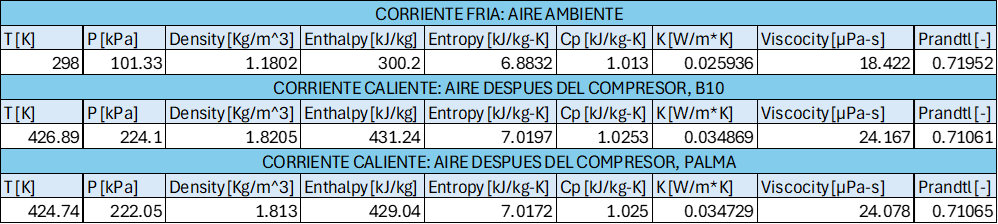

In [2]:
mostrar_imagen("TABLA_FINAL.png")

# 4. Parámetros de entrada del modelo

Para desarrollar el modelo del intercooler se definen las variables necesarias para aplicar el método efectividad-NTU. Estas variables se organizan en cuatro grupos: condiciones ambientales, propiedades del aire, parámetros geométricos del intercooler y parámetros de diseño.

---

## 4.1 Variables ambientales

Las variables ambientales corresponden a las condiciones del aire exterior. En el modelo, este aire representa la corriente fría que atraviesa el intercooler y absorbe parte del calor retirado del aire comprimido.

| Variable | Descripción | Valor | Unidad |
|---|---|---:|---|
| $T_{amb}$ | Temperatura ambiente | 298 | K |
| $P_{amb}$ | Presión atmosférica | 101325 | Pa |

La temperatura ambiente se toma como la temperatura de entrada de la corriente fría:

$$
T_{c,in} = T_{amb}
$$

La presión ambiente se toma como condición de referencia para el aire exterior:

$$
P_{c,in} = P_{amb}
$$

---

## 4.2 Propiedades termodinámicas y de transporte del aire

Como el intercooler es de tipo aire-aire, ambas corrientes corresponden al mismo fluido. Sin embargo, las propiedades del aire no se toman iguales para ambas corrientes, ya que la corriente caliente y la corriente fría se encuentran a diferentes condiciones de temperatura y presión.

Por esta razón, las propiedades del aire se obtienen mediante REFPROP para cada condición de operación. La corriente fría se evalúa a condiciones ambientales, mientras que la corriente caliente se evalúa con las condiciones de salida del compresor para cada combustible.

| Corriente | $T$ [K] | $P$ [kPa] | $\rho$ [kg/m³] | $c_p$ [kJ/(kg K)] | $k$ [W/(m K)] | $\mu$ [Pa s] | $Pr$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| Aire ambiente | 298.00 | 101.33 | 1.1802 | 1.0130 | 0.025936 | $18.422 \times 10^{-6}$ | 0.71952 |
| Aire caliente, ACPM B10 | 426.89 | 224.10 | 1.8205 | 1.0253 | 0.034869 | $24.167 \times 10^{-6}$ | 0.71061 |
| Aire caliente, biodiésel 1G palma | 424.74 | 222.05 | 1.8130 | 1.0250 | 0.034729 | $24.078 \times 10^{-6}$ | 0.71065 |

Estas propiedades se usarán posteriormente para calcular las capacitancias térmicas, los números adimensionales, los coeficientes convectivos y el coeficiente global de transferencia de calor.

Las capacitancias térmicas de las corrientes se calculan como:

$$
C_h = \dot{m}_h c_{p,h}
$$

$$
C_c = \dot{m}_c c_{p,c}
$$

donde $c_{p,h}$ corresponde al calor específico de la corriente caliente y $c_{p,c}$ al calor específico de la corriente fría.

---

## 4.3 Parámetros geométricos del intercooler

Para definir la escala física del intercooler se toma como referencia una ficha técnica comercial de un intercooler Spectra Premium tipo **bar and plate**, utilizado en aplicaciones diésel pesadas. Esta referencia permite establecer dimensiones globales del núcleo, diámetro de entrada y diámetro de salida.

El intercooler de referencia presenta las siguientes dimensiones:

| Parámetro | Valor en ficha | Valor SI | Unidad SI |
|---|---:|---:|---|
| Altura del núcleo, $H_{core}$ | 36-7/8 pulg | 0.9366 | m |
| Ancho del núcleo, $W_{core}$ | 26-3/8 pulg | 0.6699 | m |
| Espesor del núcleo, $E_{core}$ | 2-1/4 pulg | 0.0572 | m |
| Diámetro de entrada, $D_{in}$ | 4 pulg | 0.1016 | m |
| Diámetro de salida, $D_{out}$ | 4 pulg | 0.1016 | m |

A partir de las dimensiones del núcleo, se calcula el área frontal aproximada del intercooler:

$$
A_f = H_{core}W_{core}
$$

$$
A_f = (0.9366)(0.6699)
$$

$$
A_f = 0.6274 \ \text{m}^2
$$

El área de entrada del aire comprimido se estima a partir del diámetro de entrada:

$$
A_{in} = \frac{\pi D_{in}^2}{4}
$$

$$
A_{in} = \frac{\pi (0.1016)^2}{4}
$$

$$
A_{in} = 8.11 \times 10^{-3} \ \text{m}^2
$$

El área frontal $A_f$ se utilizará para estimar el flujo de aire ambiente que atraviesa el intercooler. Por su parte, el área de entrada $A_{in}$ se utilizará para estimar la velocidad de la corriente caliente a la entrada del intercooler.

Debido a que la ficha técnica no especifica el área interna real de transferencia de calor, el área de intercambio $A_s$ se calculará posteriormente mediante una geometría equivalente. Esta aproximación permite representar la superficie disponible para el intercambio térmico sin asumir una geometría interna exacta del núcleo.

---

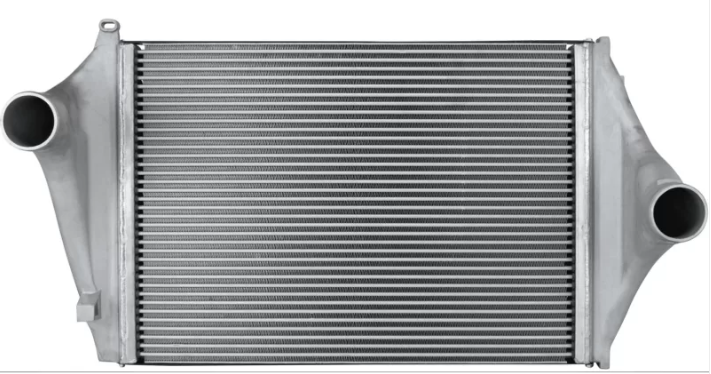

In [ ]:
mostrar_imagen("SPECTRA_INTERCOOLER.png")


## 4.4 Parámetros de diseño

El parámetro de diseño que se va a comparar es el número de pasos efectivos del aire comprimido dentro del intercooler. Este valor representa el recorrido aproximado de la corriente caliente antes de salir hacia la admisión del motor.

Se proponen tres configuraciones:

| Diseño | Número de pasos $N_p$ | Interpretación |
|---|---:|---|
| Diseño 1 | 2 | Configuración base |
| Diseño 2 | 4 | Mayor recorrido interno |
| Diseño 3 | 6 | Mayor recorrido térmico efectivo |

Al aumentar el número de pasos, aumenta la longitud recorrida por el aire comprimido dentro del intercooler. En el modelo, este efecto se representa mediante un área de transferencia equivalente:

$$
A_s(N_p)=N_h\pi D_{in}N_pL_{paso}
$$

donde $N_h$ es el número de conductos u horquillas equivalentes, $D_{in}$ es el diámetro de entrada tomado de la ficha técnica, $N_p$ es el número de pasos y $L_{paso}$ es la longitud aproximada de cada paso.

Con esta área se calcula el producto global de transferencia de calor:

$$
UA(N_p)=U A_s(N_p)
$$

El coeficiente global $U$ se calculará posteriormente a partir de los coeficientes convectivos de la corriente caliente, la corriente fría y la resistencia térmica de la pared.

También se considera que un mayor número de pasos puede aumentar la caída de presión. Como la ficha técnica no reporta este valor, la pérdida de presión se maneja como un parámetro de comparación del modelo:

$$
\Delta P_{IC}(N_p)=\beta N_p
$$

donde $\beta$ es un factor porcentual de pérdida de presión por paso. Para el análisis se toma:

$$
\beta = 0.01
$$

De esta forma, para los diseños de 2, 4 y 6 pasos se obtienen pérdidas relativas de 2 %, 4 % y 6 %, respectivamente.

La presión de salida del intercooler se calcula como:

$$
P_3=P_2(1-\Delta P_{IC})
$$

Así, el modelo permite comparar el beneficio térmico de aumentar el número de pasos con la pérdida de presión asociada al mayor recorrido del aire comprimido.



# 5. Balance de masa en el intercooler

El intercooler se analiza como un volumen de control con dos corrientes independientes: la corriente caliente, formada por el aire comprimido que viene del compresor, y la corriente fría, correspondiente al aire ambiente que atraviesa externamente el núcleo del intercooler.

Como las corrientes no se mezclan entre sí, el balance de masa se aplica por separado para cada una.

La ecuación general de conservación de masa es:

$$
\frac{dm}{dt} = \sum \dot{m}_{in} - \sum \dot{m}_{out}
$$

Para el modelo se considera operación estacionaria, por lo que no hay acumulación de masa dentro del intercooler:

$$
\frac{dm}{dt}=0
$$

Por tanto:

$$
\sum \dot{m}_{in} = \sum \dot{m}_{out}
$$

---

## 5.1 Corriente caliente

La corriente caliente corresponde al aire comprimido que sale del compresor e ingresa al intercooler. Esta corriente entra con las condiciones del Estado 2 y sale con las condiciones del Estado 3.

El balance de masa para esta corriente es:

$$
\dot{m}_{h,in}=\dot{m}_{h,out}
$$

Por tanto:

$$
\dot{m}_h=\text{constante}
$$

En este modelo, el flujo másico de la corriente caliente corresponde al aire requerido por el motor. Si este valor no se obtiene directamente del modelo de combustión, puede estimarse a partir de la potencia del compresor:

$$
\dot{W}_c = \dot{m}_h c_{p,h}(T_2-T_1)
$$

Despejando:

$$
\dot{m}_h =
\frac{\dot{W}_c}{c_{p,h}(T_2-T_1)}
$$

Las condiciones de entrada y salida de esta corriente son:

$$
T_{h,in}=T_2
$$

$$
P_{h,in}=P_2
$$

$$
T_{h,out}=T_3
$$

$$
P_{h,out}=P_3
$$

La densidad de la corriente caliente se toma a partir de REFPROP para las condiciones de entrada al intercooler, es decir, para $T_2$ y $P_2$:

$$
\rho_h=\rho(T_2,P_2)
$$

Con esta densidad, el flujo másico puede relacionarse con el área de entrada y la velocidad promedio del aire comprimido:

$$
\dot{m}_h=\rho_h A_{in}V_h
$$

Por tanto:

$$
V_h=\frac{\dot{m}_h}{\rho_h A_{in}}
$$

Esta velocidad será utilizada posteriormente para calcular el número de Reynolds de la corriente caliente.

---

## 5.2 Corriente fría

La corriente fría corresponde al aire ambiente que atraviesa externamente el intercooler y absorbe parte del calor retirado del aire comprimido.

El balance de masa para esta corriente es:

$$
\dot{m}_{c,in}=\dot{m}_{c,out}
$$

Por tanto:

$$
\dot{m}_c=\text{constante}
$$

Sus condiciones de entrada se toman como condiciones ambientales:

$$
T_{c,in}=T_{amb}
$$

$$
P_{c,in}=P_{amb}
$$

La densidad de la corriente fría se obtiene mediante REFPROP para las condiciones ambientales:

$$
\rho_c=\rho(T_{amb},P_{amb})
$$

El flujo másico de aire ambiente se estima mediante:

$$
\dot{m}_c=\rho_c A_{f,eff}V_{amb}
$$

donde el área frontal efectiva se define como:

$$
A_{f,eff}=\phi A_f
$$

Aquí, $\phi$ representa la fracción del área frontal que se considera efectiva para el paso del aire. Esto permite evitar asumir que todo el frente del intercooler participa de manera ideal en el enfriamiento.

La temperatura de salida de la corriente fría se calculará más adelante mediante el balance de energía:

$$
T_{c,out}=T_4
$$

---




# 6. Configuraciones de análisis

Con los parámetros geométricos definidos previamente, se comparan tres configuraciones del intercooler variando el número de pasos efectivos del aire comprimido:

| Diseño | Número de pasos $N_p$ | Interpretación |
|---|---:|---|
| Diseño 1 | 2 | Configuración base |
| Diseño 2 | 4 | Mayor recorrido interno |
| Diseño 3 | 6 | Mayor recorrido térmico efectivo |

En este modelo, el número de pasos no se toma como un dato exacto de la ficha técnica, sino como una variable de comparación. Su función es representar el aumento del recorrido del aire comprimido dentro del intercooler.

El área de transferencia se calculará mediante la geometría equivalente:

$$
A_s(N_p)=N_h\pi D_{in}N_pL_{paso}
$$

donde $N_h$ representa el número de conductos u horquillas equivalentes, $D_{in}$ es el diámetro de entrada y $L_{paso}$ es la longitud aproximada de cada paso.

También se considera una pérdida de presión creciente con el número de pasos. Como la ficha técnica no reporta este valor, se maneja como un supuesto de comparación del modelo:

$$
\Delta P_{IC}(N_p)=\beta N_p
$$

La presión de salida se calcula como:

$$
P_3=P_2(1-\Delta P_{IC})
$$

De esta forma, las configuraciones se comparan considerando tanto el beneficio térmico como la pérdida de presión asociada.



# 7. Modelo térmico mediante el método efectividad-NTU

El modelo térmico del intercooler se desarrolla mediante el método efectividad-NTU. Este método permite estimar el calor retirado del aire comprimido y las temperaturas de salida de ambas corrientes sin conocer previamente dichas temperaturas.

La ruta general del modelo es:

Propiedades de cada corriente  
↓  
Flujos másicos  
↓  
Capacitancias térmicas  
↓  
Reynolds y Prandtl  
↓  
Nusselt  
↓  
Coeficientes convectivos y coeficiente global $U$  
↓  
Área de transferencia  
↓  
NTU  
↓  
Efectividad térmica  
↓  
Calor retirado  
↓  
Temperaturas de salida $T_3$ y $T_4$

---

## 7.1 Propiedades de cada corriente

El intercooler se modela como un intercambiador aire-aire. Aunque ambas corrientes corresponden al mismo fluido, sus propiedades no se toman iguales, ya que la corriente caliente y la corriente fría se encuentran a diferentes condiciones de temperatura y presión.

Las propiedades del aire fueron obtenidas mediante REFPROP para las condiciones de entrada de cada corriente.

| Corriente | $T$ [K] | $P$ [kPa] | $\rho$ [kg/m³] | $c_p$ [kJ/(kg K)] | $k$ [W/(m K)] | $\mu$ [Pa s] | $Pr$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| Aire ambiente | 298.00 | 101.33 | 1.1802 | 1.0130 | 0.025936 | $18.422 \times 10^{-6}$ | 0.71952 |
| Aire caliente, ACPM B10 | 426.89 | 224.10 | 1.8205 | 1.0253 | 0.034869 | $24.167 \times 10^{-6}$ | 0.71061 |
| Aire caliente, biodiésel 1G palma | 424.74 | 222.05 | 1.8130 | 1.0250 | 0.034729 | $24.078 \times 10^{-6}$ | 0.71065 |

Estas propiedades se utilizan para calcular las capacitancias térmicas, los números adimensionales, los coeficientes convectivos y el coeficiente global de transferencia de calor.

---

## 7.2 Flujos másicos de las corrientes

La corriente caliente corresponde al aire comprimido que sale del compresor. El flujo másico de esta corriente se estima a partir de la potencia del compresor:

$$
\dot{W}_c = \dot{m}_h c_{p,h}(T_2-T_1)
$$

Despejando:

$$
\dot{m}_h =
\frac{\dot{W}_c}{c_{p,h}(T_2-T_1)}
$$

Para ACPM B10:

$$
\dot{m}_{h,B10} =
\frac{17.941}{1.0253(426.89-298)}
$$

$$
\dot{m}_{h,B10} = 0.1358 \ \text{kg/s}
$$

Para biodiésel 1G palma:

$$
\dot{m}_{h,palma} =
\frac{16.619}{1.0250(424.74-298)}
$$

$$
\dot{m}_{h,palma} = 0.1279 \ \text{kg/s}
$$

La corriente fría corresponde al aire ambiente que atraviesa externamente el núcleo del intercooler. Se fija una velocidad de aire ambiente de:

$$
V_{amb} = 10 \ \text{m/s}
$$

El flujo másico de aire ambiente se calcula como:

$$
\dot{m}_c = \rho_c A_{f,eff}V_{amb}
$$

donde el área frontal efectiva se define como:

$$
A_{f,eff} = \phi A_f
$$

Como no toda el área frontal del intercooler participa de manera ideal en el paso del aire, se toma una fracción efectiva:

$$
\phi = 0.2
$$

Por tanto:

$$
\dot{m}_c = \rho_c \phi A_f V_{amb}
$$

Usando:

$$
\rho_c = 1.1802 \ \text{kg/m}^3
$$

$$
A_f = 0.6274 \ \text{m}^2
$$

$$
V_{amb} = 10 \ \text{m/s}
$$

se obtiene:

$$
\dot{m}_c = 1.1802(0.2)(0.6274)(10)
$$

$$
\dot{m}_c = 1.481 \ \text{kg/s}
$$

Los flujos másicos utilizados en el modelo son:

| Corriente | Caso | Flujo másico [kg/s] |
|---|---|---:|
| Corriente caliente | ACPM B10 | 0.1358 |
| Corriente caliente | Biodiésel 1G palma | 0.1279 |
| Corriente fría | Aire ambiente | 1.481 |

---

## 7.3 Capacitancias térmicas de las corrientes

La capacitancia térmica representa la capacidad de cada corriente para transportar energía térmica por unidad de diferencia de temperatura.

Para la corriente caliente:

$$
C_h = \dot{m}_h c_{p,h}
$$

Para la corriente fría:

$$
C_c = \dot{m}_c c_{p,c}
$$

Como los valores de $c_p$ se obtuvieron en kJ/(kg K), para el cálculo de las capacitancias se convierten a J/(kg K).

Para la corriente fría:

$$
C_c = (1.481)(1013)
$$

$$
C_c = 1500.2 \ \text{W/K}
$$

Para ACPM B10:

$$
C_{h,B10} = (0.1358)(1025.3)
$$

$$
C_{h,B10} = 139.2 \ \text{W/K}
$$

Para biodiésel 1G palma:

$$
C_{h,palma} = (0.1279)(1025.0)
$$

$$
C_{h,palma} = 131.1 \ \text{W/K}
$$

---

## 7.4 Capacitancia mínima, capacitancia máxima y relación de capacidades

Para aplicar el método efectividad-NTU se definen:

$$
C_{min} = \min(C_h,C_c)
$$

$$
C_{max} = \max(C_h,C_c)
$$

y la relación de capacidades:

$$
C_r = \frac{C_{min}}{C_{max}}
$$

Con la fracción efectiva de área seleccionada, la corriente fría sigue teniendo mayor capacitancia térmica que la corriente caliente. Por tanto, la corriente caliente continúa siendo la corriente limitante térmicamente.

Para ACPM B10:

$$
C_{min} = C_{h,B10} = 139.2 \ \text{W/K}
$$

$$
C_{max} = C_c = 1500.2 \ \text{W/K}
$$

$$
C_{r,B10} = \frac{139.2}{1500.2}
$$

$$
C_{r,B10} = 0.0928
$$

Para biodiésel 1G palma:

$$
C_{min} = C_{h,palma} = 131.1 \ \text{W/K}
$$

$$
C_{max} = C_c = 1500.2 \ \text{W/K}
$$

$$
C_{r,palma} = \frac{131.1}{1500.2}
$$

$$
C_{r,palma} = 0.0874
$$

El hecho de que $C_{min}$ corresponda a la corriente caliente indica que el aire comprimido es el flujo que limita la cantidad máxima de calor que puede retirarse en el intercooler.

---

## 7.5 Cálculo del número de Reynolds

El número de Reynolds permite identificar el régimen de flujo de cada corriente. Para una corriente de aire se calcula como:

$$
Re = \frac{\rho V D_{car}}{\mu}
$$

donde $\rho$ es la densidad del aire, $V$ es la velocidad promedio, $D_{car}$ es la longitud característica y $\mu$ es la viscosidad dinámica.

En este modelo, el número de Prandtl fue obtenido directamente de REFPROP para cada condición de operación.

---

### 7.5.1 Reynolds de la corriente caliente

La corriente caliente corresponde al aire comprimido proveniente del compresor. Para esta corriente se toma como diámetro característico el diámetro de entrada del intercooler:

$$
D_{car,h} = D_{in}
$$

La velocidad promedio de la corriente caliente se calcula a partir del balance de masa:

$$
V_h = \frac{\dot{m}_h}{\rho_h A_{in}}
$$

Para ACPM B10:

$$
V_{h,B10} =
\frac{0.1358}{(1.8205)(8.11\times10^{-3})}
$$

$$
V_{h,B10} = 9.20 \ \text{m/s}
$$

Entonces:

$$
Re_{h,B10} =
\frac{(1.8205)(9.20)(0.1016)}{24.167\times10^{-6}}
$$

$$
Re_{h,B10} = 7.04\times10^4
$$

Para biodiésel 1G palma:

$$
V_{h,palma} =
\frac{0.1279}{(1.8130)(8.11\times10^{-3})}
$$

$$
V_{h,palma} = 8.70 \ \text{m/s}
$$

Entonces:

$$
Re_{h,palma} =
\frac{(1.8130)(8.70)(0.1016)}{24.078\times10^{-6}}
$$

$$
Re_{h,palma} = 6.65\times10^4
$$

En ambos casos, el valor de Reynolds indica que la corriente caliente se encuentra en régimen turbulento.

---

### 7.5.2 Reynolds de la corriente fría

La corriente fría corresponde al aire ambiente que atraviesa externamente el núcleo del intercooler. Para esta corriente se toma como longitud característica el espesor del núcleo, ya que representa la distancia aproximada recorrida por el aire ambiente al atravesar el intercambiador:

$$
D_{car,c} = E_{core}
$$

La velocidad del aire ambiente se fijó como:

$$
V_{amb} = 10 \ \text{m/s}
$$

Por tanto:

$$
Re_c =
\frac{\rho_c V_{amb}E_{core}}{\mu_c}
$$

Reemplazando:

$$
Re_c =
\frac{(1.1802)(10)(0.0572)}{18.422\times10^{-6}}
$$

$$
Re_c = 3.66\times10^4
$$

Este valor también corresponde a un régimen turbulento para la corriente fría.

---

### 7.5.3 Resumen de Reynolds y Prandtl

| Corriente | Caso | $Re$ | $Pr$ | Régimen |
|---|---|---:|---:|---|
| Caliente | ACPM B10 | $7.04\times10^4$ | 0.71061 | Turbulento |
| Caliente | Biodiésel 1G palma | $6.65\times10^4$ | 0.71065 | Turbulento |
| Fría | Aire ambiente | $3.66\times10^4$ | 0.71952 | Turbulento |

---
## 7.6 Cálculo del número de Nusselt

El número de Nusselt permite estimar los coeficientes convectivos de las corrientes. Una vez calculado, el coeficiente de convección se obtiene mediante:

$$
h=\frac{Nu\,k}{D_{car}}
$$

En el intercooler se consideran dos tipos de flujo:

- La corriente caliente se aproxima como flujo interno turbulento, ya que circula por conductos internos.
- La corriente fría se aproxima como flujo externo cruzado equivalente, ya que el aire ambiente atraviesa el núcleo del intercooler.

---

### 7.6.1 Corriente caliente

Para la corriente caliente se usa la correlación de Dittus-Boelter:

$$
Nu_h=0.023Re_h^{4/5}Pr_h^n
$$

Como el aire comprimido se está enfriando, se toma:

$$
n=0.3
$$

Por tanto:

$$
Nu_h=0.023Re_h^{4/5}Pr_h^{0.3}
$$

Aplicando esta correlación a los dos combustibles se obtiene:

| Caso | $Re_h$ | $Pr_h$ | $Nu_h$ |
|---|---:|---:|---:|
| ACPM B10 | $7.04\times10^4$ | 0.71061 | 156.8 |
| Biodiésel 1G palma | $6.65\times10^4$ | 0.71065 | 149.8 |

---

### 7.6.2 Corriente fría

Para la corriente fría se usa una correlación de flujo externo cruzado:

$$
Nu_c=CRe_c^mPr_c^{1/3}
$$

El valor de Reynolds obtenido para el aire ambiente fue:

$$
Re_c=3.66\times10^4
$$

Este valor se encuentra en el rango:

$$
4000 < Re_c < 40000
$$



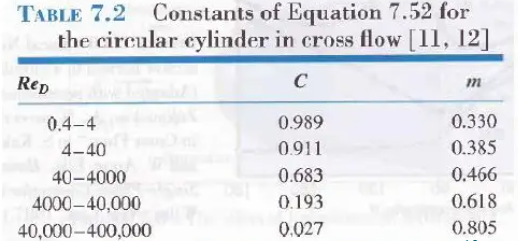

In [ ]:
mostrar_imagen("Tabla_Nu.png")



A partir de la tabla de constantes para cilindro en flujo cruzado se toman:



$$
C = 0.193
$$

$$
m = 0.618
$$

Por tanto, la correlación queda:

$$
Nu_c=0.193Re_c^{0.618}Pr_c^{1/3}
$$

Con:

$$
Pr_c=0.71952
$$

se obtiene:

$$
Nu_c=114.3
$$

La tabla permite justificar la selección de los coeficientes $C$ y $m$ usados en la correlación.

---

### 7.6.3 Resumen de Nusselt

| Corriente | Caso | Correlación | $Nu$ |
|---|---|---|---:|
| Caliente | ACPM B10 | Flujo interno turbulento | 156.8 |
| Caliente | Biodiésel 1G palma | Flujo interno turbulento | 149.8 |
| Fría | Aire ambiente | Flujo externo cruzado equivalente | 114.3 |

---

## 7.7 Coeficientes convectivos y coeficiente global $U$

Con los números de Nusselt se calculan los coeficientes convectivos:

$$
h=\frac{Nu\,k}{D_{car}}
$$

Para la corriente caliente:

$$
h_h=\frac{Nu_hk_h}{D_{in}}
$$

Para la corriente fría:

$$
h_c=\frac{Nu_ck_c}{E_{core}}
$$

Los valores obtenidos son:

| Caso | $h_h$ [W/(m² K)] | $h_c$ [W/(m² K)] |
|---|---:|---:|
| ACPM B10 | 53.8 | 51.8 |
| Biodiésel 1G palma | 51.2 | 51.8 |

El coeficiente global de transferencia de calor se calcula considerando las resistencias convectivas de ambas corrientes y la resistencia conductiva de la pared:

$$
\frac{1}{U}=
\frac{1}{h_h}
+
\frac{e_{Al}}{k_{Al}}
+
\frac{1}{h_c}
$$

Para la pared de aluminio se toman:

$$
e_{Al}=1.0\times10^{-3} \ \text{m}
$$

$$
k_{Al}=205 \ \text{W/(m K)}
$$

Los valores finales usados en el modelo son:

| Caso | $U$ [W/(m² K)] |
|---|---:|
| ACPM B10 | 26.4 |
| Biodiésel 1G palma | 25.8 |
---
## 7.8 Cálculo del NTU

El número de unidades de transferencia se calcula como:

$$
NTU=\frac{UA_s}{C_{min}}
$$

donde $U$ es el coeficiente global de transferencia de calor, $A_s$ es el área de transferencia y $C_{min}$ es la capacitancia térmica mínima.

---

### 7.8.1 Área de transferencia del intercooler

Para estimar el área de transferencia se usa una geometría equivalente basada en la relación:

$$
A_s=\pi DL
$$

El diámetro se toma de la ficha técnica del intercooler:

$$
D=D_{in}=0.1016 \ \text{m}
$$

La longitud de un paso se aproxima con el ancho del núcleo:

$$
L_{paso}=W_{core}=0.6699 \ \text{m}
$$

Como el intercooler real no se comporta como un único conducto, se introduce un número de conductos u horquillas equivalentes:

$$
N_h=3
$$

Este valor no corresponde a una geometría exacta del fabricante, sino a una aproximación para representar que el intercambio no ocurre en un solo conducto.

La longitud efectiva recorrida por el aire comprimido depende del número de pasos:

$$
L_{eff}(N_p)=N_pL_{paso}
$$

Por tanto, el área de transferencia queda:

$$
A_s(N_p)=N_h\pi D_{in}N_pL_{paso}
$$

Con esta expresión se calcula el área para los diseños de 2, 4 y 6 pasos.

---

### 7.8.2 Cálculo de $NTU$

Para cada combustible se usa:

$$
NTU_{B10}(N_p)=\frac{U_{B10}A_s(N_p)}{C_{min,B10}}
$$

$$
NTU_{palma}(N_p)=\frac{U_{palma}A_s(N_p)}{C_{min,palma}}
$$

El valor de $NTU$ aumenta con el número de pasos, ya que aumenta la longitud efectiva de intercambio y, por tanto, el área disponible para transferir calor. Los valores numéricos se obtienen directamente en el código computacional.

---



### 7.8.3 NTU para cada combustible

Con el área de transferencia definida, el NTU para cada diseño queda dado por:

$$
NTU(N_p) =
\frac{U A_s(N_p)}{C_{min}}
$$

Para ACPM B10:

$$
NTU_{B10}(N_p) =
\frac{26.4 A_s(N_p)}{139.2}
$$

Para biodiésel 1G palma:

$$
NTU_{palma}(N_p) =
\frac{25.8 A_s(N_p)}{131.1}
$$

Los resultados obtenidos son:

| Diseño | $N_p$ | $A_s$ [m²] | $NTU_{B10}$ | $NTU_{palma}$ |
|---|---:|---:|---:|---:|
| Diseño 1 | 2 | 0.428 | 0.081 | 0.084 |
| Diseño 2 | 4 | 0.855 | 0.162 | 0.168 |
| Diseño 3 | 6 | 1.283 | 0.243 | 0.252 |

El valor de $NTU$ aumenta con el número de pasos, ya que el recorrido efectivo de intercambio también aumenta. Sin embargo, al usar una estimación geométrica conservadora del área, los valores de $NTU$ no se sobredimensionan.

---

## 7.9 Cálculo de la efectividad térmica

La efectividad térmica indica qué fracción del máximo calor posible realmente se retira en el intercooler.

Para la configuración multipaso equivalente se usa:

$$
\varepsilon =
2
\left[
1 + C_r + \sqrt{1+C_r^2}
\left(
\frac{
1+\exp[-NTU\sqrt{1+C_r^2}]
}{
1-\exp[-NTU\sqrt{1+C_r^2}]
}
\right)
\right]^{-1}
$$

donde:

$$
C_r=\frac{C_{min}}{C_{max}}
$$

En este modelo:

$$
C_{r,B10}=0.0928
$$

$$
C_{r,palma}=0.0874
$$

Además del cálculo numérico, la gráfica de efectividad-NTU se utiliza como verificación cualitativa. Para valores de $C_r$ cercanos a 0.1 y los $NTU$ calculados, la gráfica permite comprobar que las efectividades se encuentran en un rango coherente con los resultados del código.



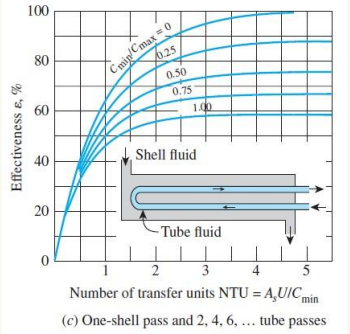

In [ ]:
mostrar_imagen("efectividad.png")


## 7.10 Calor máximo posible y calor real retirado

Una vez calculada la efectividad térmica, se determina el calor máximo que podría retirarse de la corriente caliente:

$$
\dot{Q}_{max}=C_{min}(T_{h,in}-T_{c,in})
$$

Para este modelo:

$$
T_{h,in}=T_2
$$

$$
T_{c,in}=T_{amb}
$$

Por tanto:

$$
\dot{Q}_{max}=C_{min}(T_2-T_{amb})
$$

El calor real retirado por el intercooler se calcula como:

$$
\dot{Q}_{IC}=\varepsilon\dot{Q}_{max}
$$

o equivalentemente:

$$
\dot{Q}_{IC}=\varepsilon C_{min}(T_2-T_{amb})
$$

Este cálculo se realiza en el código para cada combustible y para cada configuración de pasos.

---

## 7.11 Temperaturas de salida $T_3$ y $T_4$

Las temperaturas de salida se obtienen mediante el balance de energía del intercooler.

Para la corriente caliente:

$$
T_3=T_2-\frac{\dot{Q}_{IC}}{C_h}
$$

Para la corriente fría:

$$
T_4=T_{amb}+\frac{\dot{Q}_{IC}}{C_c}
$$

Los valores finales de $T_3$ y $T_4$ se reportan en la tabla generada por el código computacional.

---

## 7.12 Presión y densidad de salida del intercooler

Además del enfriamiento, se considera la caída de presión asociada al paso del aire por el intercooler. La presión de salida se calcula como:

$$
P_3=P_2(1-\Delta P_{IC})
$$

Como la ficha técnica no reporta este valor, se maneja como un parámetro del modelo. Para comparar los diseños se adopta una pérdida relativa creciente con el número de pasos:

$$
\Delta P_{IC}(N_p)=\beta N_p
$$

con:

$$
\beta=0.01
$$

Así, los diseños de 2, 4 y 6 pasos corresponden a pérdidas relativas de 2 %, 4 % y 6 %, respectivamente.

La densidad del aire a la salida se estima mediante:

$$
\rho_3=\frac{P_3}{R_{air}T_3}
$$

Estos cálculos permiten evaluar si el aumento de densidad producido por el enfriamiento compensa parcialmente la pérdida de presión del intercooler. Los resultados finales se presentan en la tabla generada por el código.


Relación de capacidades térmicas:
Cr_B10   = 0.0928
Cr_palma = 0.0874

Calor máximo posible:
Qmax_B10   = 17.94 kW
Qmax_palma = 16.62 kW

Resultados completos del intercooler:


,Np,Nh,As_m2,NTU_B10,epsilon_B10,epsilon_B10_%,QIC_B10_kW,T3_B10_K,T4_B10_K,P3_B10_kPa,rho3_B10_kg_m3,rho3_rho2_B10,NTU_palma,epsilon_palma,epsilon_palma_%,QIC_palma_kW,T3_palma_K,T4_palma_K,P3_palma_kPa,rho3_palma_kg_m3,rho3_rho2_palma
0,2,3,1.2829,0.2433,0.2138,21.3825,3.8363,399.3301,300.5572,219.618,1.9163,1.0526,0.2525,0.2210,22.0964,3.6714,396.7351,300.4473,217.609,1.9111,1.0541
1,4,3,2.5659,0.4866,0.3785,37.8490,6.7907,378.1065,302.5265,215.136,1.9825,1.0890,0.5050,0.3897,38.9667,6.4746,375.3536,302.3158,213.168,1.9788,1.0914
2,6,3,3.8488,0.7299,0.5058,50.5774,9.0743,361.7008,304.0488,210.654,2.0293,1.1147,0.7574,0.5190,51.8957,8.6228,358.9674,303.7478,208.727,2.0260,1.1175


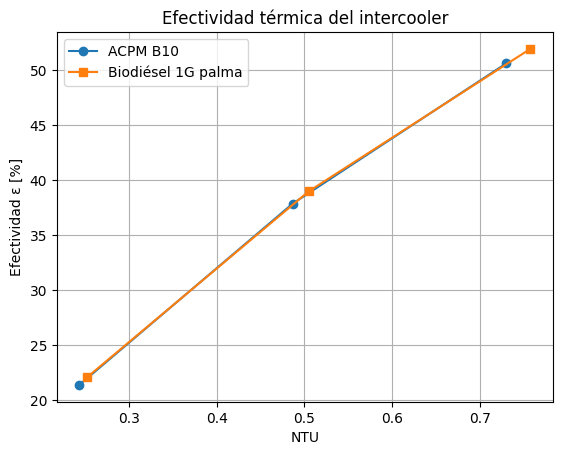

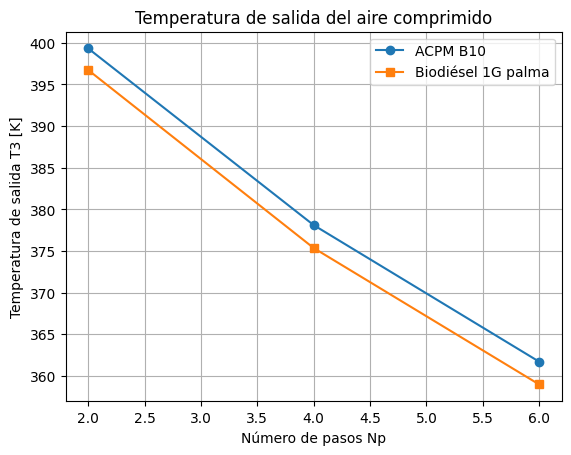

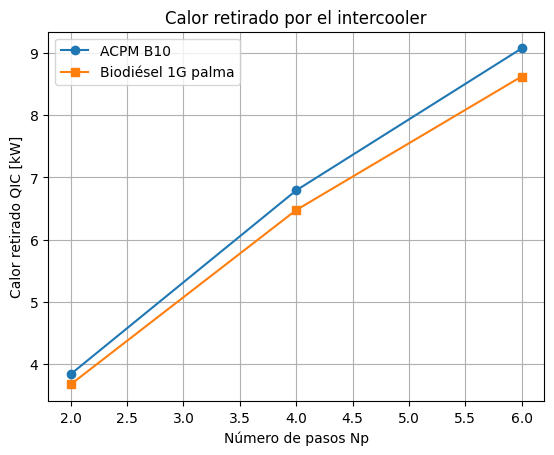

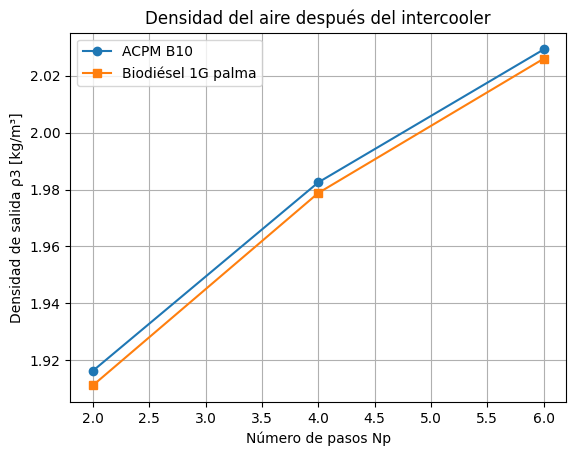

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#parametros

Np = np.array([2, 4, 6])       # numero de pasos
Nh = 3                         # horquillas

dP_frac = np.array([0.02, 0.04, 0.06])  # Caída de presión por diseño

Din = 0.1016       # diametro de entreada m
L_paso = 0.6699    # longitud de un paso m

#otros datos, la mayoria salen del modelo del compresor

Cmin_B10 = 139.2
Cmin_palma = 131.1
Cmax = 1500.2

Cr_B10 = Cmin_B10 / Cmax
Cr_palma = Cmin_palma / Cmax

T2_B10 = 426.89
T2_palma = 424.74
Tamb = 298.0

U_B10 = 26.4
U_palma = 25.8

P2_B10 = 224.10
P2_palma = 222.05

R_air = 287

rho2_B10 = 1.8205
rho2_palma = 1.8130

#calculos

As = Nh * np.pi * Din * Np * L_paso

NTU_B10 = U_B10 * As / Cmin_B10
NTU_palma = U_palma * As / Cmin_palma

def epsilon_shell_tube(NTU, Cr):
    raiz = np.sqrt(1 + Cr**2)
    return 2 / (
        1 + Cr + raiz * (
            (1 + np.exp(-NTU * raiz)) /
            (1 - np.exp(-NTU * raiz))
        )
    )

eps_B10 = epsilon_shell_tube(NTU_B10, Cr_B10)
eps_palma = epsilon_shell_tube(NTU_palma, Cr_palma)

Qmax_B10 = Cmin_B10 * (T2_B10 - Tamb)
Qmax_palma = Cmin_palma * (T2_palma - Tamb)

QIC_B10 = eps_B10 * Qmax_B10
QIC_palma = eps_palma * Qmax_palma

T3_B10 = T2_B10 - QIC_B10 / Cmin_B10
T3_palma = T2_palma - QIC_palma / Cmin_palma

T4_B10 = Tamb + QIC_B10 / Cmax
T4_palma = Tamb + QIC_palma / Cmax

P3_B10 = P2_B10 * (1 - dP_frac)
P3_palma = P2_palma * (1 - dP_frac)

rho3_B10 = (P3_B10 * 1000) / (R_air * T3_B10)
rho3_palma = (P3_palma * 1000) / (R_air * T3_palma)

rho3_rho2_B10 = rho3_B10 / rho2_B10
rho3_rho2_palma = rho3_palma / rho2_palma

# =resultados

resultados = pd.DataFrame({
    "Np": Np,
    "Nh": Nh,
    "As_m2": As,
    "NTU_B10": NTU_B10,
    "epsilon_B10": eps_B10,
    "epsilon_B10_%": eps_B10 * 100,
    "QIC_B10_kW": QIC_B10 / 1000,
    "T3_B10_K": T3_B10,
    "T4_B10_K": T4_B10,
    "P3_B10_kPa": P3_B10,
    "rho3_B10_kg_m3": rho3_B10,
    "rho3_rho2_B10": rho3_rho2_B10,
    "NTU_palma": NTU_palma,
    "epsilon_palma": eps_palma,
    "epsilon_palma_%": eps_palma * 100,
    "QIC_palma_kW": QIC_palma / 1000,
    "T3_palma_K": T3_palma,
    "T4_palma_K": T4_palma,
    "P3_palma_kPa": P3_palma,
    "rho3_palma_kg_m3": rho3_palma,
    "rho3_rho2_palma": rho3_rho2_palma
})

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

print("Relación de capacidades térmicas:")
print(f"Cr_B10   = {Cr_B10:.4f}")
print(f"Cr_palma = {Cr_palma:.4f}\n")

print("Calor máximo posible:")
print(f"Qmax_B10   = {Qmax_B10/1000:.2f} kW")
print(f"Qmax_palma = {Qmax_palma/1000:.2f} kW\n")

print("Resultados completos del intercooler:")
display(resultados)


plt.figure()
plt.plot(NTU_B10, eps_B10 * 100, "o-", linewidth=1.5, label="ACPM B10")
plt.plot(NTU_palma, eps_palma * 100, "s-", linewidth=1.5, label="Biodiésel 1G palma")
plt.grid(True)
plt.xlabel("NTU")
plt.ylabel("Efectividad ε [%]")
plt.title("Efectividad térmica del intercooler")
plt.legend()
plt.show()

plt.figure()
plt.plot(Np, T3_B10, "o-", linewidth=1.5, label="ACPM B10")
plt.plot(Np, T3_palma, "s-", linewidth=1.5, label="Biodiésel 1G palma")
plt.grid(True)
plt.xlabel("Número de pasos Np")
plt.ylabel("Temperatura de salida T3 [K]")
plt.title("Temperatura de salida del aire comprimido")
plt.legend()
plt.show()

plt.figure()
plt.plot(Np, QIC_B10 / 1000, "o-", linewidth=1.5, label="ACPM B10")
plt.plot(Np, QIC_palma / 1000, "s-", linewidth=1.5, label="Biodiésel 1G palma")
plt.grid(True)
plt.xlabel("Número de pasos Np")
plt.ylabel("Calor retirado QIC [kW]")
plt.title("Calor retirado por el intercooler")
plt.legend()
plt.show()

plt.figure()
plt.plot(Np, rho3_B10, "o-", linewidth=1.5, label="ACPM B10")
plt.plot(Np, rho3_palma, "s-", linewidth=1.5, label="Biodiésel 1G palma")
plt.grid(True)
plt.xlabel("Número de pasos Np")
plt.ylabel("Densidad de salida ρ3 [kg/m³]")
plt.title("Densidad del aire después del intercooler")
plt.legend()
plt.show()




## 7.13 Respuesta transitoria del intercooler

Después de obtener los valores estacionarios del intercooler, se analiza cómo evoluciona la salida del sistema con el tiempo. Para esto se usa una aproximación de primer orden, donde la temperatura de salida del aire comprimido tiende progresivamente hacia el valor calculado mediante el método efectividad-NTU.

La dinámica de la temperatura de salida se plantea como:

$$
\frac{dT_3(t)}{dt} =
\frac{T_{3,ss}-T_3(t)}{\tau_{IC}}
$$

donde $T_{3,ss}$ es la temperatura de salida en estado estacionario y $\tau_{IC}$ es la constante de tiempo térmica del intercooler.

La solución de esta ecuación es:

$$
T_3(t)=T_{3,ss}+\left(T_{3,0}-T_{3,ss}\right)e^{-t/\tau_{IC}}
$$

Como condición inicial se toma:

$$
T_{3,0}=T_2
$$

Esto representa el instante inicial en el que el aire comprimido aún no ha sido enfriado por el intercooler.

El calor retirado durante el transitorio se calcula como una respuesta progresiva hacia el valor estacionario:

$$
\dot{Q}_{IC}(t)=\dot{Q}_{IC,ss}\left(1-e^{-t/\tau_{IC}}\right)
$$

De forma equivalente, también puede interpretarse a partir del balance de energía de la corriente caliente:

$$
\dot{Q}_{IC}(t)=C_h\left[T_2-T_3(t)\right]
$$

La densidad de salida se calcula en cada instante mediante la ecuación de gas ideal:

$$
\rho_3(t)=\frac{P_3}{R_{air}T_3(t)}
$$

En este modelo, la constante de tiempo $\tau_{IC}$ se maneja como un parámetro de simulación, ya que la ficha técnica del intercooler no reporta la masa térmica del núcleo ni su capacidad calorífica equivalente. Para el análisis se toma:

$$
\tau_{IC}=30 \ \text{s}
$$

Con esta aproximación se evalúa la evolución temporal de la temperatura de salida, el calor retirado y la densidad del aire comprimido para cada configuración del intercooler.


Constante de tiempo usada: tau_IC = 30.0 s
Tiempo aproximado para alcanzar 63% de la respuesta: 30.0 s
Tiempo aproximado para alcanzar 95% de la respuesta: 90.0 s



,Np,T3_B10_tau_K,T3_B10_3tau_K,T3_B10_final_K,QIC_B10_final_kW,rho3_B10_final_kg_m3,T3_palma_tau_K,T3_palma_3tau_K,T3_palma_final_K,QIC_palma_final_kW,rho3_palma_final_kg_m3
0,2,409.3929,400.7126,399.3984,3.8268,1.9159,406.9603,398.1399,396.8045,3.6623,1.9108
1,4,395.9185,380.5536,378.2274,6.7738,1.9819,393.3857,377.8310,375.4760,6.4585,1.9781
2,6,385.5029,364.9709,361.8624,9.0518,2.0284,382.9826,362.2668,359.1305,8.6014,2.0251


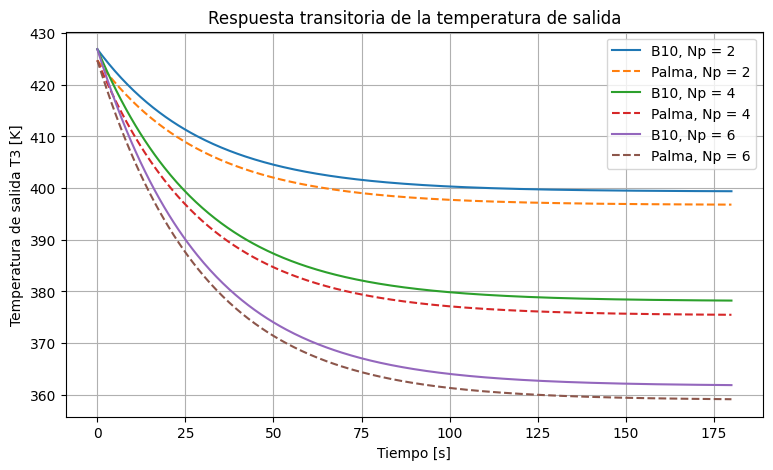

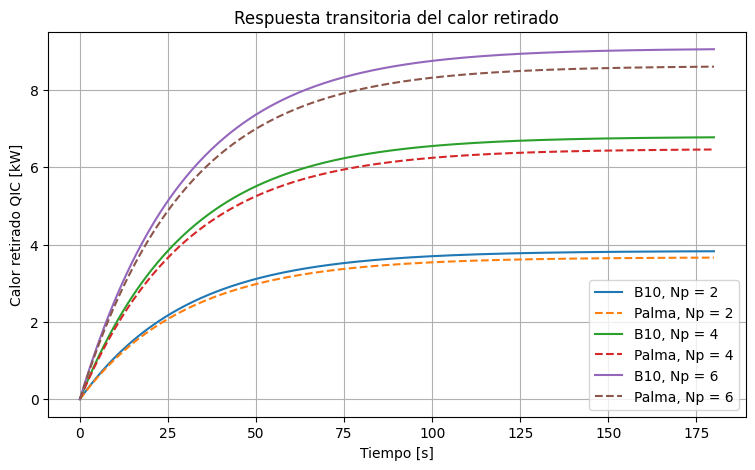

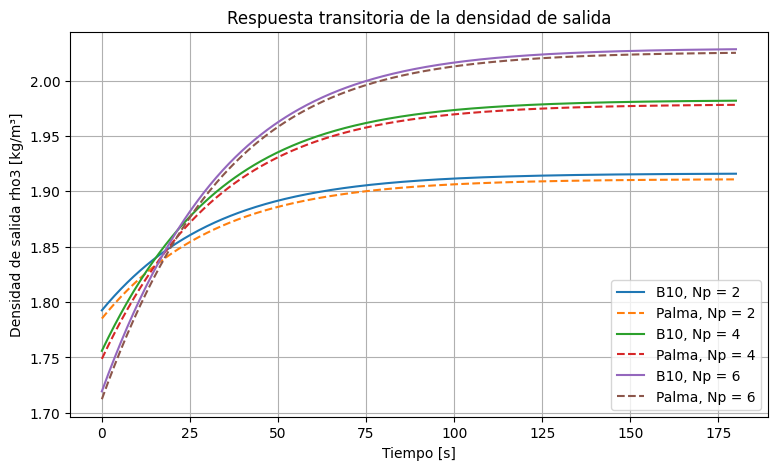

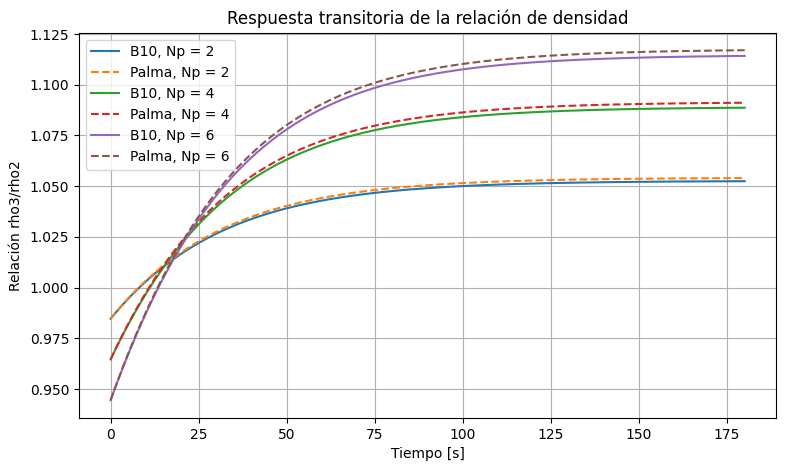

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ==============================
# PARÁMETROS MODIFICABLES
# ==============================

tau_IC = 30.0      # Constante de tiempo térmica del intercooler [s]
t_final = 180      # Tiempo total de simulación [s]
n_puntos = 400     # Resolución temporal

# ==============================
# VERIFICACIÓN DE VARIABLES DEL MODELO ESTACIONARIO
# ==============================

variables_necesarias = [
    "Np", "T2_B10", "T2_palma", "T3_B10", "T3_palma",
    "QIC_B10", "QIC_palma", "P3_B10", "P3_palma",
    "rho2_B10", "rho2_palma", "R_air"
]

faltantes = [var for var in variables_necesarias if var not in globals()]

if faltantes:
    raise NameError(
        "Faltan variables del modelo estacionario. "
        "Ejecuta primero el código estacionario. Variables faltantes: "
        + ", ".join(faltantes)
    )

# ==============================
# PREPARACIÓN DE DATOS
# ==============================

Np = np.asarray(Np, dtype=float)

T3_B10 = np.asarray(T3_B10, dtype=float)
T3_palma = np.asarray(T3_palma, dtype=float)

QIC_B10 = np.asarray(QIC_B10, dtype=float)
QIC_palma = np.asarray(QIC_palma, dtype=float)

P3_B10 = np.asarray(P3_B10, dtype=float)
P3_palma = np.asarray(P3_palma, dtype=float)

t = np.linspace(0, t_final, n_puntos)

# ==============================
# MODELO TRANSITORIO DE PRIMER ORDEN
# ==============================

def respuesta_transitoria(T0, Tss, Qss, P3, rho2):
    T_t = Tss[:, None] + (T0 - Tss)[:, None] * np.exp(-t / tau_IC)
    Q_t = Qss[:, None] * (1 - np.exp(-t / tau_IC))
    rho_t = (P3[:, None] * 1000) / (R_air * T_t)
    rho_rel_t = rho_t / rho2
    return T_t, Q_t, rho_t, rho_rel_t

T3t_B10, QICt_B10, rho3t_B10, rho_rel_t_B10 = respuesta_transitoria(
    T2_B10, T3_B10, QIC_B10, P3_B10, rho2_B10
)

T3t_palma, QICt_palma, rho3t_palma, rho_rel_t_palma = respuesta_transitoria(
    T2_palma, T3_palma, QIC_palma, P3_palma, rho2_palma
)

# ==============================
# TABLA RESUMEN TRANSITORIA
# ==============================

idx_63 = np.argmin(np.abs(t - tau_IC))
idx_95 = np.argmin(np.abs(t - 3 * tau_IC))
idx_final = -1

resumen_transitorio = pd.DataFrame({
    "Np": Np.astype(int),
    "T3_B10_tau_K": T3t_B10[:, idx_63],
    "T3_B10_3tau_K": T3t_B10[:, idx_95],
    "T3_B10_final_K": T3t_B10[:, idx_final],
    "QIC_B10_final_kW": QICt_B10[:, idx_final] / 1000,
    "rho3_B10_final_kg_m3": rho3t_B10[:, idx_final],
    "T3_palma_tau_K": T3t_palma[:, idx_63],
    "T3_palma_3tau_K": T3t_palma[:, idx_95],
    "T3_palma_final_K": T3t_palma[:, idx_final],
    "QIC_palma_final_kW": QICt_palma[:, idx_final] / 1000,
    "rho3_palma_final_kg_m3": rho3t_palma[:, idx_final]
})

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

print(f"Constante de tiempo usada: tau_IC = {tau_IC:.1f} s")
print(f"Tiempo aproximado para alcanzar 63% de la respuesta: {tau_IC:.1f} s")
print(f"Tiempo aproximado para alcanzar 95% de la respuesta: {3*tau_IC:.1f} s\n")

display(resumen_transitorio)

# ==============================
# GRÁFICAS
# ==============================

labels = [f"Np = {int(n)}" for n in Np]

plt.figure(figsize=(9, 5))
for i, label in enumerate(labels):
    plt.plot(t, T3t_B10[i], label=f"B10, {label}")
    plt.plot(t, T3t_palma[i], "--", label=f"Palma, {label}")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Temperatura de salida T3 [K]")
plt.title("Respuesta transitoria de la temperatura de salida")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
for i, label in enumerate(labels):
    plt.plot(t, QICt_B10[i] / 1000, label=f"B10, {label}")
    plt.plot(t, QICt_palma[i] / 1000, "--", label=f"Palma, {label}")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Calor retirado QIC [kW]")
plt.title("Respuesta transitoria del calor retirado")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
for i, label in enumerate(labels):
    plt.plot(t, rho3t_B10[i], label=f"B10, {label}")
    plt.plot(t, rho3t_palma[i], "--", label=f"Palma, {label}")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Densidad de salida rho3 [kg/m³]")
plt.title("Respuesta transitoria de la densidad de salida")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
for i, label in enumerate(labels):
    plt.plot(t, rho_rel_t_B10[i], label=f"B10, {label}")
    plt.plot(t, rho_rel_t_palma[i], "--", label=f"Palma, {label}")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Relación rho3/rho2")
plt.title("Respuesta transitoria de la relación de densidad")
plt.legend()
plt.show()


# 8. Resultados del modelo estacionario del intercooler

A partir del modelo efectividad-NTU se evaluó el comportamiento estacionario del intercooler para tres configuraciones de diseño, definidas por el número de pasos efectivos del aire comprimido:

$$
N_p = 2,\ 4,\ 6
$$

Los resultados permiten comparar el efecto del número de pasos sobre la efectividad térmica, el calor retirado, la temperatura de salida del aire comprimido y la densidad del aire a la entrada del motor.

---

## 8.1 Efectividad térmica

La efectividad térmica aumenta al incrementar el número de pasos. Esto ocurre porque un mayor número de pasos representa un mayor recorrido efectivo del aire comprimido dentro del intercooler, lo que incrementa el área disponible para transferencia de calor.

Para ACPM B10, la efectividad pasa aproximadamente de:

$$
\varepsilon = 21.38\%
$$

en el diseño de 2 pasos, a:

$$
\varepsilon = 50.58\%
$$

en el diseño de 6 pasos.

Para el biodiésel 1G de palma se presenta una tendencia similar, pasando de:

$$
\varepsilon = 22.10\%
$$

a:

$$
\varepsilon = 51.90\%
$$

El biodiésel de palma presenta una efectividad ligeramente mayor que el ACPM B10 en las tres configuraciones. Sin embargo, la diferencia entre ambos combustibles es pequeña, por lo que el comportamiento térmico general del intercooler es bastante similar en los dos casos.

---

## 8.2 Calor retirado por el intercooler

El calor retirado por el intercooler también aumenta con el número de pasos. Para ACPM B10, el calor retirado cambia aproximadamente de:

$$
\dot{Q}_{IC} = 3.84 \ \text{kW}
$$

en el diseño de 2 pasos, a:

$$
\dot{Q}_{IC} = 9.07 \ \text{kW}
$$

en el diseño de 6 pasos.

Para el biodiésel 1G de palma, el calor retirado aumenta de:

$$
\dot{Q}_{IC} = 3.67 \ \text{kW}
$$

a:

$$
\dot{Q}_{IC} = 8.62 \ \text{kW}
$$

Aunque la efectividad del biodiésel de palma es ligeramente mayor, el ACPM B10 presenta un calor retirado mayor. Esto se debe a que el caso B10 tiene una temperatura de entrada y una carga térmica máxima ligeramente superiores.

---

## 8.3 Temperatura de salida del aire comprimido

La temperatura de salida del aire comprimido disminuye al aumentar el número de pasos. Para ACPM B10, la temperatura pasa de:

$$
T_3 = 399.33 \ \text{K}
$$

en el diseño de 2 pasos, a:

$$
T_3 = 361.70 \ \text{K}
$$

en el diseño de 6 pasos.

Para el biodiésel 1G de palma, la temperatura disminuye de:

$$
T_3 = 396.74 \ \text{K}
$$

a:

$$
T_3 = 358.97 \ \text{K}
$$

Estos resultados muestran que el diseño de 6 pasos logra el mayor enfriamiento del aire comprimido antes de su entrada al motor. Sin embargo, esta mejora térmica debe analizarse junto con la caída de presión generada por el intercooler.

---

## 8.4 Presión y densidad de salida

Al aumentar el número de pasos, la presión de salida del intercooler disminuye debido a la mayor resistencia al flujo. Para ACPM B10, la presión de salida pasa de:

$$
P_3 = 219.62 \ \text{kPa}
$$

a:

$$
P_3 = 210.65 \ \text{kPa}
$$

entre los diseños de 2 y 6 pasos.

A pesar de esta caída de presión, la densidad del aire aumenta debido a la reducción de temperatura. Para ACPM B10, la densidad pasa de:

$$
\rho_3 = 1.916 \ \text{kg/m}^3
$$

a:

$$
\rho_3 = 2.029 \ \text{kg/m}^3
$$

Para el biodiésel 1G de palma se observa el mismo comportamiento, con un aumento de densidad desde:

$$
\rho_3 = 1.911 \ \text{kg/m}^3
$$

hasta:

$$
\rho_3 = 2.026 \ \text{kg/m}^3
$$

Esto indica que el enfriamiento generado por el intercooler compensa parcialmente la pérdida de presión, permitiendo una mayor densidad del aire disponible para la admisión del motor.

---

## 8.5 Comparación de diseños

El diseño de 2 pasos presenta la menor caída de presión, pero también el menor enfriamiento. El diseño de 4 pasos representa una condición intermedia entre transferencia de calor y pérdida de presión. El diseño de 6 pasos ofrece el mejor desempeño térmico, ya que presenta la mayor efectividad, el mayor calor retirado y la mayor densidad de salida.

Desde el punto de vista térmico, el diseño de 6 pasos es el más favorable. No obstante, desde el punto de vista del sistema completo, debe considerarse que este diseño también genera la mayor caída de presión. Por tanto, la selección final no depende únicamente del enfriamiento, sino del equilibrio entre reducción de temperatura, aumento de densidad y presión disponible a la entrada del motor.

---

## 8.6 Conclusión del modelo estacionario

El análisis estacionario muestra que aumentar el número de pasos del intercooler mejora el desempeño térmico del sistema. Al incrementar el recorrido efectivo del aire comprimido, aumenta el área de transferencia, el NTU y la efectividad térmica.

El diseño de 6 pasos presenta los mejores resultados térmicos, ya que permite retirar más calor, reducir en mayor medida la temperatura de salida y aumentar la densidad del aire que ingresa al motor. Para ACPM B10, este diseño reduce la temperatura de salida hasta aproximadamente 361.70 K y aumenta la densidad hasta 2.029 kg/m³. Para el biodiésel 1G de palma, la temperatura se reduce hasta 358.97 K y la densidad alcanza 2.026 kg/m³.

Sin embargo, este mejor desempeño térmico viene acompañado de una mayor caída de presión. Por esta razón, el intercooler no debe evaluarse únicamente por su capacidad de enfriamiento, sino también por la presión disponible después del dispositivo.

En términos generales, el modelo estacionario permite concluir que el intercooler mejora las condiciones de admisión del motor al reducir la temperatura del aire comprimido y aumentar su densidad, aunque existe un compromiso entre transferencia de calor y pérdida de presión.



# 9. Resultados de la respuesta transitoria

Después de evaluar el comportamiento estacionario del intercooler, se analiza la respuesta transitoria del sistema. Para esto se usa una aproximación de primer orden con una constante de tiempo:

$$
\tau_{IC}=30 \ \text{s}
$$

Bajo esta aproximación, el intercooler alcanza aproximadamente el 63 % de su respuesta a los 30 s y cerca del 95 % a los 90 s. Por tanto, el intervalo de simulación de 180 s permite observar prácticamente el establecimiento completo del sistema.

---

## 9.1 Temperatura de salida del aire comprimido

La temperatura de salida $T_3(t)$ disminuye progresivamente desde la temperatura de salida del compresor hasta el valor estacionario calculado mediante el método efectividad-NTU.

En todos los casos, el diseño con mayor número de pasos alcanza una menor temperatura final. Para ACPM B10, el diseño de 6 pasos llega aproximadamente a:

$$
T_3 \approx 361.86 \ \text{K}
$$

mientras que el diseño de 2 pasos se estabiliza cerca de:

$$
T_3 \approx 399.40 \ \text{K}
$$

Para el biodiésel 1G de palma se observa el mismo comportamiento, con una temperatura final cercana a:

$$
T_3 \approx 359.13 \ \text{K}
$$

para el diseño de 6 pasos.

Esto confirma que, durante el transitorio, el aumento del número de pasos permite un enfriamiento más fuerte del aire comprimido.

---

## 9.2 Calor retirado durante el transitorio

El calor retirado por el intercooler parte de un valor inicial cercano a cero y aumenta hasta alcanzar el valor estacionario correspondiente a cada diseño.

El diseño de 6 pasos presenta el mayor calor retirado durante toda la respuesta. Para ACPM B10, el valor final se aproxima a:

$$
\dot{Q}_{IC} \approx 9.05 \ \text{kW}
$$

mientras que para el biodiésel 1G de palma se aproxima a:

$$
\dot{Q}_{IC} \approx 8.60 \ \text{kW}
$$

Este resultado es consistente con el modelo estacionario: al aumentar el número de pasos, aumenta el área efectiva de transferencia y, por tanto, aumenta la capacidad del intercooler para retirar calor.

---

## 9.3 Densidad de salida del aire comprimido

La densidad de salida $\rho_3(t)$ aumenta con el tiempo debido a la reducción de temperatura del aire comprimido. Aunque los diseños con mayor número de pasos presentan una mayor caída de presión, el enfriamiento logrado compensa parcialmente esta pérdida.

Al final del transitorio, el diseño de 6 pasos alcanza las mayores densidades:

$$
\rho_{3,B10} \approx 2.028 \ \text{kg/m}^3
$$

$$
\rho_{3,palma} \approx 2.025 \ \text{kg/m}^3
$$

Esto muestra que el intercooler no solo reduce la temperatura de admisión, sino que también mejora la densidad del aire disponible para el motor.

---

## 9.4 Relación de densidad $\rho_3/\rho_2$

La relación $\rho_3/\rho_2$ permite comparar la densidad del aire después del intercooler con la densidad a la salida del compresor.

En los primeros instantes, los diseños con mayor número de pasos pueden iniciar con una relación de densidad menor debido a la caída de presión considerada. Sin embargo, a medida que el aire se enfría, la densidad aumenta y el diseño de 6 pasos termina presentando la mayor relación final.

Para ACPM B10, el diseño de 6 pasos alcanza aproximadamente:

$$
\frac{\rho_3}{\rho_2} \approx 1.114
$$

Para el biodiésel 1G de palma:

$$
\frac{\rho_3}{\rho_2} \approx 1.117
$$

Esto indica que, aun considerando pérdida de presión, el enfriamiento del aire permite obtener una densidad final mayor que la existente a la salida caliente del compresor.

---


## 9.5 Conclusión del modelo transitorio

La respuesta transitoria muestra que el intercooler se estabiliza de forma progresiva hacia los valores obtenidos en el análisis estacionario. Con la constante de tiempo asumida de 30 s, el sistema alcanza la mayor parte de su respuesta en aproximadamente 90 s.

El diseño de 6 pasos presenta el mejor desempeño térmico durante el transitorio, ya que logra la menor temperatura de salida, el mayor calor retirado y la mayor densidad final del aire comprimido. Sin embargo, también es el diseño asociado a la mayor caída de presión, por lo que su selección debe evaluarse considerando el comportamiento del sistema completo.

En general, el modelo transitorio confirma la tendencia observada en el análisis estacionario: aumentar el número de pasos mejora el enfriamiento y la densidad del aire de admisión, pero también aumenta la penalización hidráulica del intercooler.




# 10. Acoplamiento combustión-compresor-intercooler

Una vez desarrollado el modelo del compresor y el modelo térmico del intercooler, se realiza un acoplamiento con la cinética de combustión para evaluar cómo cambian las condiciones de admisión del motor.

El acoplamiento se plantea de forma cuasiestacionaria. En este caso, el compresor se considera en régimen estacionario y entrega las condiciones de salida del aire comprimido. Luego, el intercooler se modela con una respuesta transitoria de primer orden, de manera que la temperatura y la densidad del aire de admisión cambian con el tiempo.

La secuencia del modelo es:

$$
\text{Compresor estacionario}
\rightarrow
\text{Intercooler transitorio}
\rightarrow
\lambda_{IC}(t)
\rightarrow
\text{Cinética de combustión}
$$

---

## 10.1 Condiciones de entrada al compresor

Primero se calcula el flujo másico de combustible a partir de la potencia térmica requerida por el motor:

$$
\dot{m}_f=\frac{\dot{Q}_{motor}}{LHV}
$$

Luego, con la relación aire-combustible estequiométrica y el exceso de aire base, se estima el flujo másico de aire requerido:

$$
\dot{m}_{a,base}=\lambda_{base}AFR_{st}\dot{m}_f
$$

Este flujo de aire entra al modelo del compresor.

---

## 10.2 Salida del compresor

El compresor toma el aire ambiente y lo lleva a una condición de mayor presión y temperatura. Para cada combustible, el modelo entrega:

$$
P_2
$$

$$
T_2
$$

$$
\rho_2
$$

La densidad después del compresor se calcula como:

$$
\rho_2=\frac{P_2}{R_{air}T_2}
$$

Con esta densidad se obtiene el aumento relativo respecto al aire ambiente:

$$
\frac{\rho_2}{\rho_1}
$$

y se calcula el nuevo exceso de aire asociado al compresor:

$$
\lambda_{turbo}=\lambda_{base}\frac{\rho_2}{\rho_1}
$$

Este valor representa la mayor disponibilidad de aire debido a la compresión.

---

## 10.3 Respuesta del intercooler

La salida del compresor se usa como entrada de la corriente caliente del intercooler. Por tanto:

$$
T_{h,in}=T_2
$$

$$
P_{h,in}=P_2
$$

Primero, el intercooler se resuelve en estado estacionario mediante el método efectividad-NTU. Con esto se obtienen los valores finales de salida:

$$
T_{3,ss}
$$

$$
P_3
$$

$$
\rho_{3,ss}
$$

Después, para representar el cambio con el tiempo, se usa un modelo de primer orden:

$$
T_3(t)=T_{3,ss}+\left(T_2-T_{3,ss}\right)e^{-t/\tau_{IC}}
$$

donde $\tau_{IC}$ es la constante de tiempo térmica del intercooler. Para este caso se toma:

$$
\tau_{IC}=30 \ \text{s}
$$

Con la temperatura transitoria se calcula la densidad de salida:

$$
\rho_3(t)=\frac{P_3}{R_{air}T_3(t)}
$$

Así se puede ver cómo el enfriamiento del aire comprimido aumenta progresivamente la densidad disponible para la admisión.

---


## 10.4 Exceso de aire con intercooler

Para acoplar el intercooler con la cinética de combustión, se asume que el motor mantiene aproximadamente el mismo volumen de admisión por ciclo. Bajo esta idea, si la densidad del aire aumenta, también aumenta la masa de aire disponible para la combustión.

Por esta razón, el exceso de aire efectivo se corrige usando la relación entre la densidad de salida del intercooler y la densidad ambiente:

$$
\lambda_{IC}(t)=\lambda_{base}\frac{\rho_3(t)}{\rho_1}
$$

donde $\rho_3(t)$ es la densidad del aire después del intercooler y $\rho_1$ es la densidad del aire ambiente antes de la compresión.

Esta expresión no representa un acoplamiento completo del sistema de admisión, sino una corrección simplificada por densidad. Su propósito es estimar cómo el enfriamiento del aire comprimido puede aumentar la masa de aire disponible para el motor y, por tanto, modificar el exceso de aire usado en la cinética.

Al inicio de la respuesta transitoria, el aire todavía se encuentra cercano a la temperatura de salida del compresor. Por eso, la densidad de admisión aún no alcanza su valor final. A medida que el intercooler enfría el aire, $\rho_3(t)$ aumenta y también lo hace el valor de $\lambda_{IC}(t)$.


---

## 10.5 Evaluación de la cinética

La cinética de combustión se evalúa para varios instantes de la respuesta del intercooler:

$$
t = 0,\ \tau_{IC},\ 2\tau_{IC},\ 3\tau_{IC},\ 6\tau_{IC}
$$

En cada instante se toma el valor correspondiente de $\lambda_{IC}(t)$ y se ejecuta el modelo cinético. Con esto se observa cómo cambia la evolución de las especies principales:

$$
O_2
$$

$$
CO
$$

$$
CO_2
$$

De esta forma se comparan tres condiciones:

| Caso | Descripción |
|---|---|
| Base | Motor sin compresor |
| Compresor | Motor con aire comprimido |
| Compresor + intercooler | Motor con aire comprimido y enfriado |

---


## 10.6 Efecto del intercooler sobre la combustión

El compresor aumenta la presión y la densidad del aire, pero también eleva su temperatura. Por esta razón, al agregar el intercooler se busca reducir la temperatura del aire comprimido antes de su entrada al motor.

En el modelo, esta reducción de temperatura permite aumentar la densidad de admisión, incluso teniendo en cuenta la caída de presión dentro del intercooler. Por eso, el exceso de aire efectivo tiende a ser mayor cuando se incluye el enfriamiento:

$$
\lambda_{IC}(t)>\lambda_{turbo}>\lambda_{base}
$$

Esto significa que, bajo la aproximación usada, el sistema con intercooler dispone de más aire para el proceso de combustión.

En los resultados cinéticos se observa principalmente un aumento del oxígeno disponible y del oxígeno residual al final de la simulación. El $CO_2$ final cambia poco, ya que la cantidad de combustible se mantiene igual en todos los casos. En cambio, el pico de $CO$ puede variar ligeramente porque el aumento de oxígeno modifica la velocidad con la que se forma y se oxida el monóxido de carbono.

Por tanto, el intercooler no aumenta la energía química del combustible. Su aporte está en mejorar las condiciones del aire de admisión: reduce la temperatura, aumenta la densidad y permite una mayor disponibilidad de oxígeno para la combustión.


---



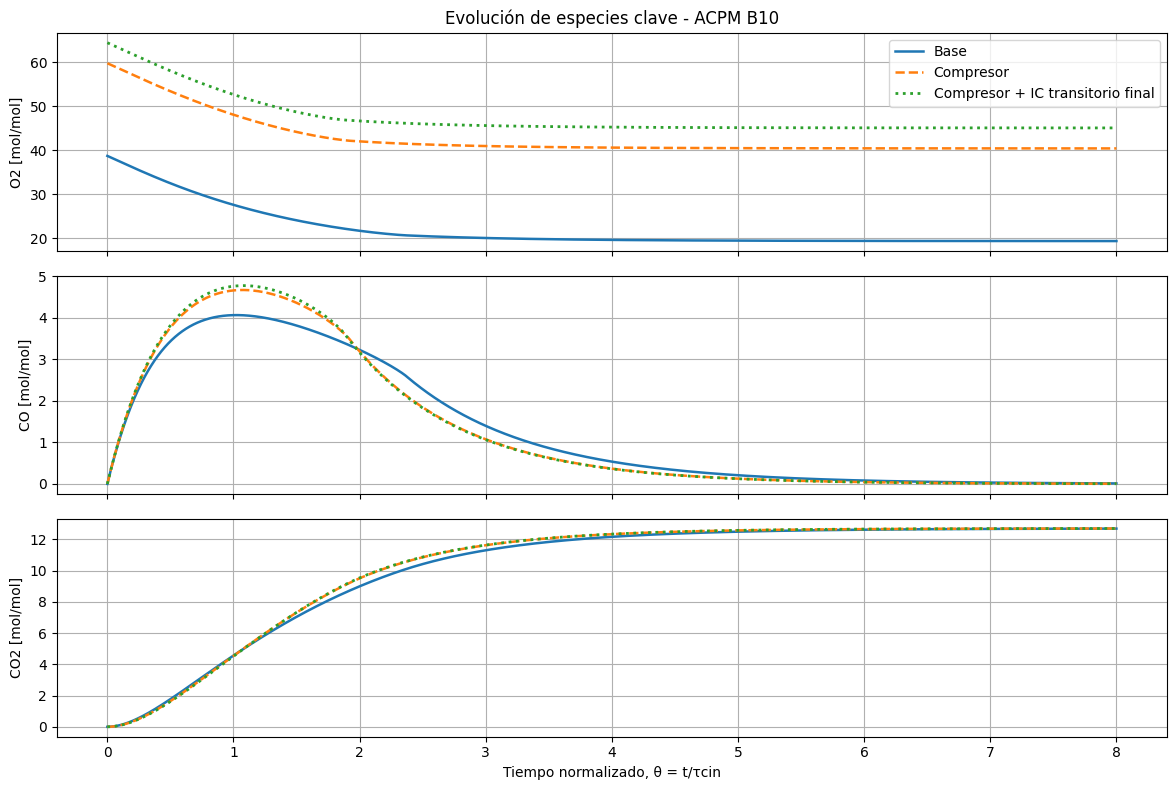

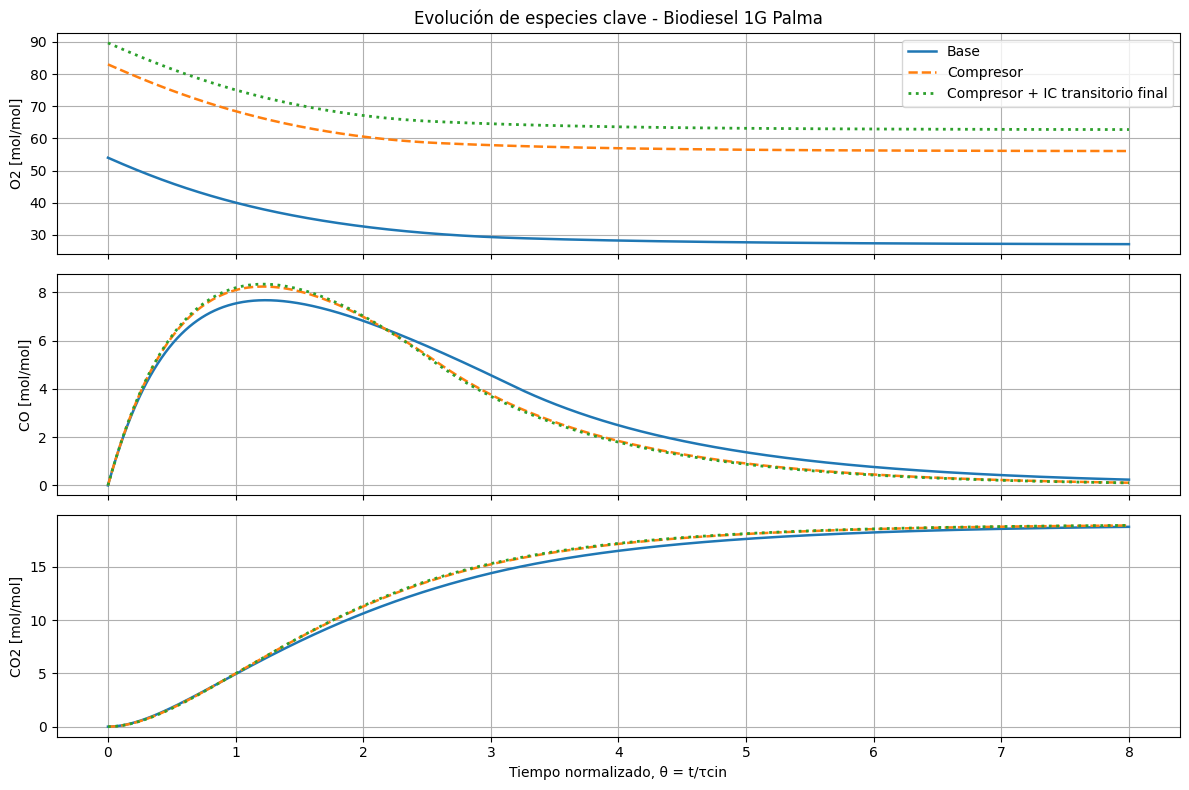

RESULTADOS COMPRESOR + COMBUSTION


,Combustible,AFR_st,lambda_base,lambda_turbo,Pi_C,P2_kPa,T2_K,rho2_rho1
0,ACPM B10,14.6917,2,3.0878,2.2117,224.0968,426.8914,1.5439
1,Biodiesel 1G Palma,12.5577,2,3.0751,2.1915,222.0491,424.7417,1.5375


RESULTADOS CUASIESTACIONARIOS: INTERCOOLER TRANSITORIO + CINETICA


,Combustible,Np,t_IC_s,lambda_IC_t,T3_t_K,rho3_t_kg_m3,COmax,CO2_final,O2_final
0,ACPM B10,2,0.0,3.0260,426.8914,1.7925,4.6461,12.6947,39.2064
1,ACPM B10,2,30.0,3.1292,412.8222,1.8536,4.6930,12.6948,41.2019
2,ACPM B10,2,60.0,3.1682,407.7299,1.8768,4.7104,12.6949,41.9581
3,ACPM B10,2,90.0,3.1830,405.8425,1.8855,4.7169,12.6949,42.2432
4,ACPM B10,2,180.0,3.1913,404.7858,1.8904,4.7206,12.6949,42.4040
5,ACPM B10,4,0.0,2.9643,426.8914,1.7559,4.6172,12.6946,38.0115
6,ACPM B10,4,30.0,3.1524,401.4136,1.8674,4.7034,12.6948,41.6519
7,ACPM B10,4,60.0,3.2265,392.1921,1.9113,4.7360,12.6949,43.0862
8,ACPM B10,4,90.0,3.2549,388.7741,1.9281,4.7482,12.6949,43.6351
9,ACPM B10,4,180.0,3.2710,386.8605,1.9376,4.7552,12.6949,43.9466


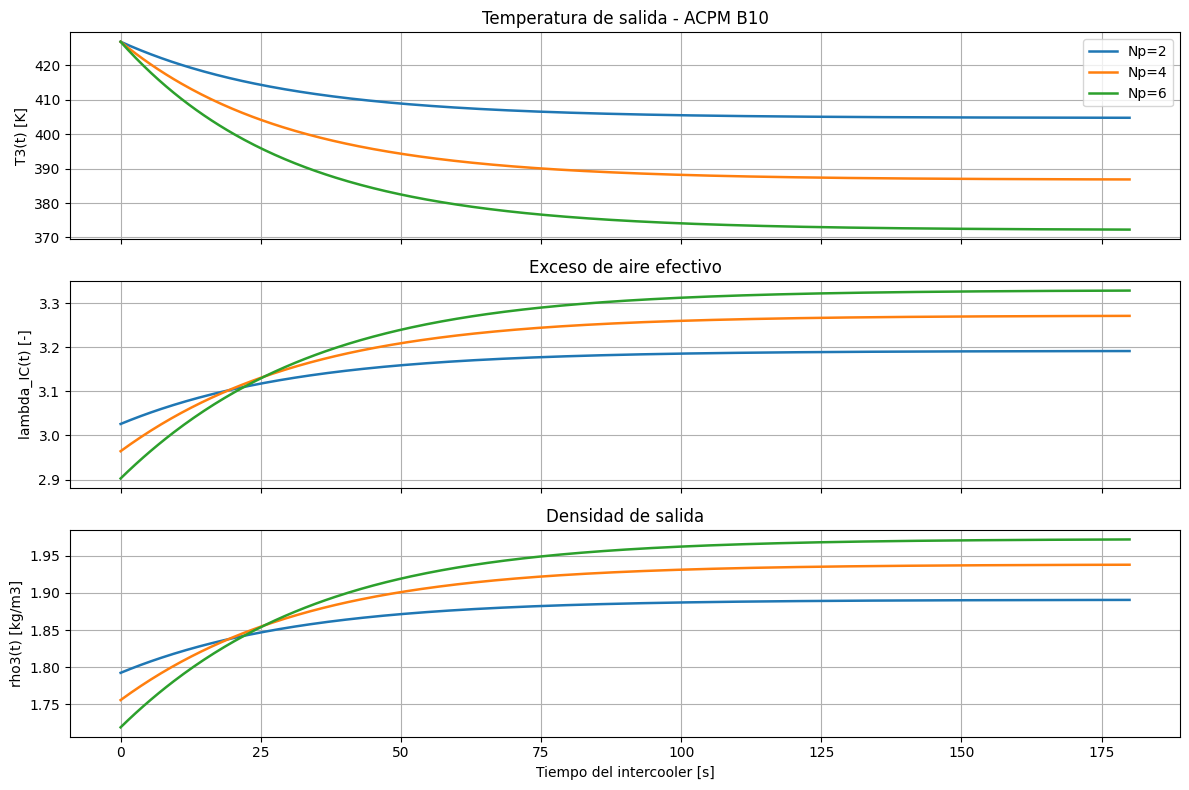

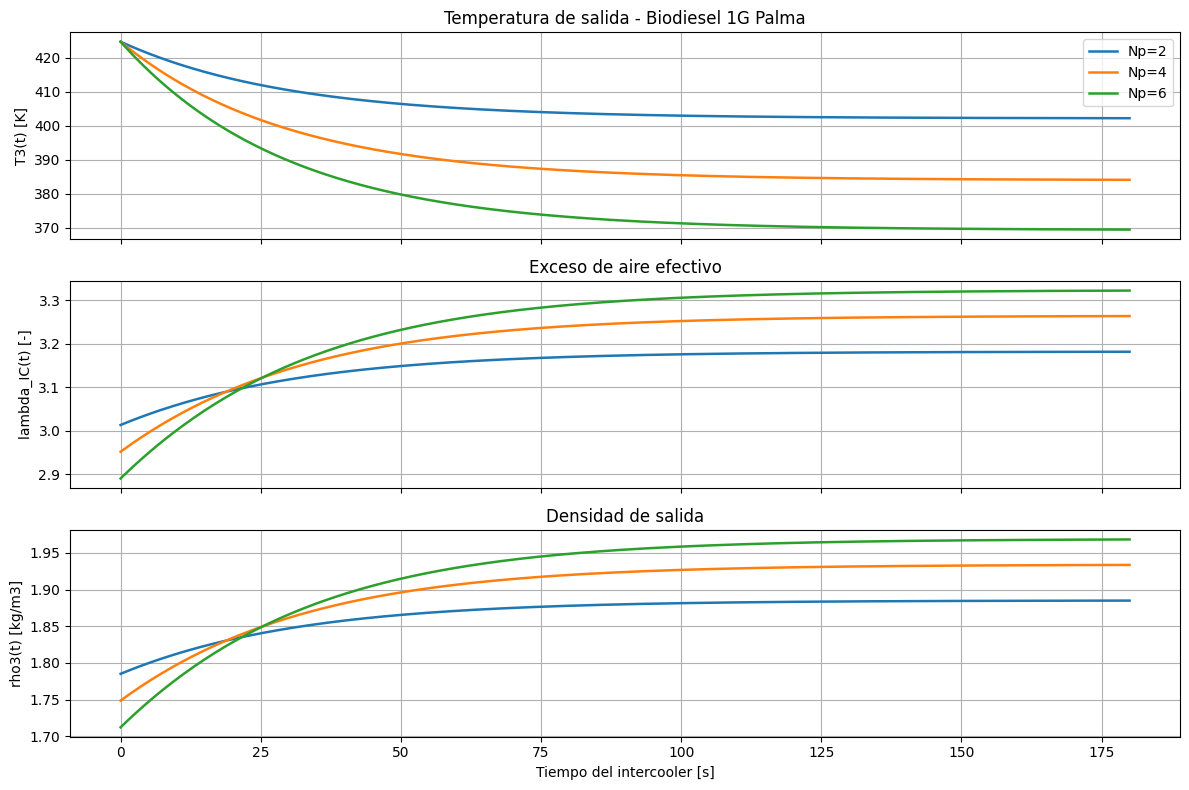

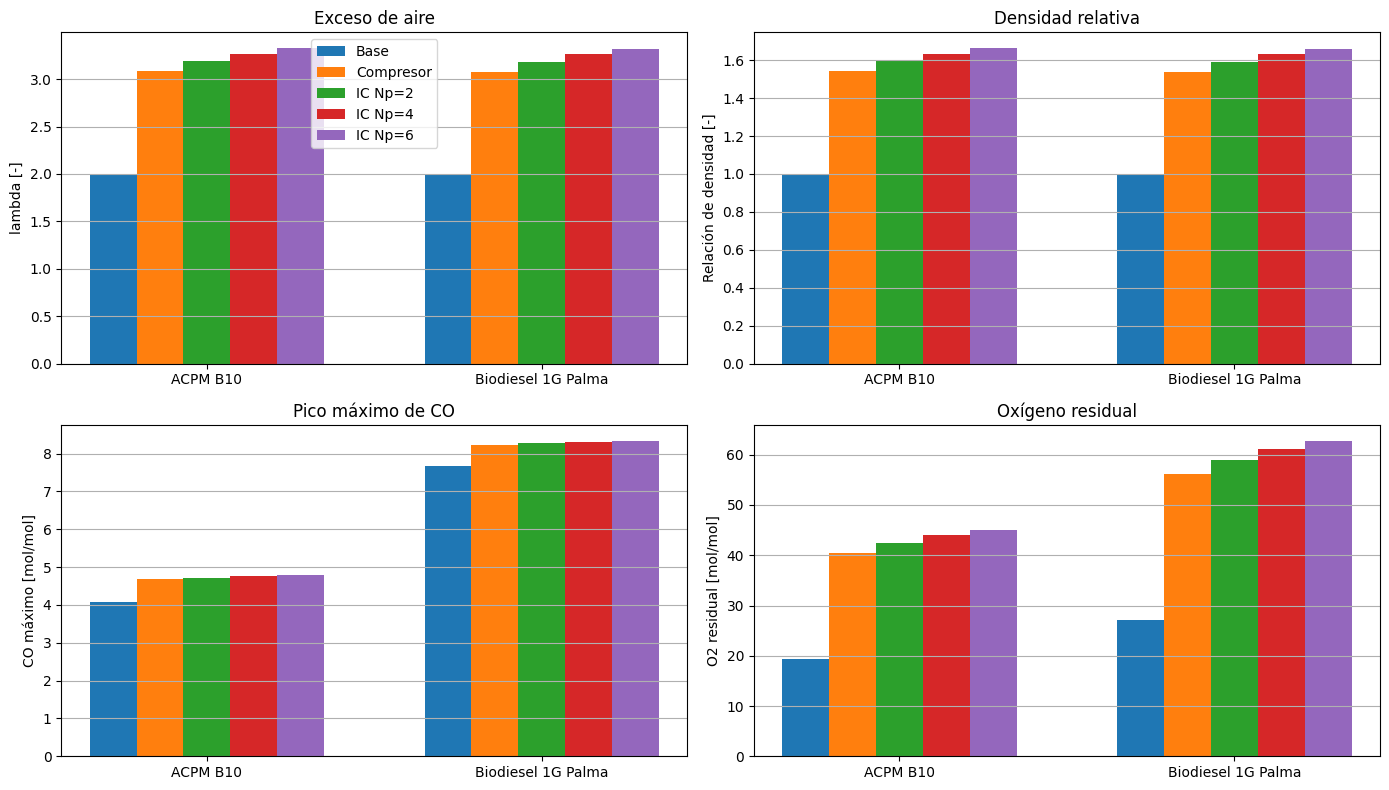

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# parametros

R = 8.3144e-3          # kJ/(mol*K)
T_cinetica = 1200      # K
F0 = 1.0               # mol inicial normalizado
Npasos = 12000

lambda_base = 2
Qdot_motor = 250e3     # Watts

# Datos del aire ambiente (Tinf)

P1 = 101325            # Pa
T1 = 298               # K
R_air = 287            # J/(kg*K)
rho1 = P1 / (R_air * T1)

# Parametros del compresor

N = 150000             # revoluciones

D1 = 0.0347            # m
D2 = 0.049             # m

r1 = D1 / 2
r2 = D2 / 2

b1 = 0.006             # m
b2 = 0.008             # m

beta1 = np.deg2rad(50)
beta2 = np.deg2rad(65)

omega_c = 2 * np.pi * N / 60

cp = 1005              # J/(kg*K)
eta_c = 0.80
g = 9.81

#Parametros del intercooler

Np_IC = np.array([2, 4, 6])
nIC = len(Np_IC)

tau_IC = 30            # s
t_final_IC = 180       # s
nt_IC = 400

t_IC_vec = np.linspace(0, t_final_IC, nt_IC)

t_eval_IC = np.array([0, tau_IC, 2*tau_IC, 3*tau_IC, 6*tau_IC])
nt_eval = len(t_eval_IC)

idx_eval = np.array([np.argmin(np.abs(t_IC_vec - t_eval)) for t_eval in t_eval_IC])



def crear_combustible(nombre, formula, x, y, z, a1, b, c, a_total,
                      A1, Ea1, alpha1, beta1, PM, LHV):
    return {
        "nombre": nombre,
        "formula": formula,
        "x": x,
        "y": y,
        "z": z,
        "a1": a1,
        "b": b,
        "c": c,
        "a_total": a_total,
        "A1": A1,
        "Ea1": Ea1,
        "alpha1": alpha1,
        "beta1": beta1,
        "PM": PM,
        "LHV": LHV
    }


def preparar_parametros(p, R, T, A2, Ea2, alpha2, beta2):
    p = p.copy()
    p["R"] = R
    p["T"] = T
    p["A2"] = A2
    p["Ea2"] = Ea2
    p["alpha2"] = alpha2
    p["beta2"] = beta2
    return p


def calcular_k(A, Ea, R, T):
    return A * np.exp(-Ea / (R * T))


def modelo_combustion(y, p):
    F = max(y[0], 0)
    O2 = max(y[1], 0)
    CO = max(y[2], 0)

    k1 = calcular_k(p["A1"], p["Ea1"], p["R"], p["T"])
    k2 = calcular_k(p["A2"], p["Ea2"], p["R"], p["T"])

    r1 = k1 * (F ** p["alpha1"]) * (O2 ** p["beta1"])
    r2 = k2 * (CO ** p["alpha2"]) * (O2 ** p["beta2"])

    dFdt = -r1
    dO2dt = -p["a1"] * r1 - 0.5 * r2
    dCOdt = p["b"] * r1 - r2
    dCO2dt = r2
    dH2Odt = p["c"] * r1

    return np.array([dFdt, dO2dt, dCOdt, dCO2dt, dH2Odt])


def rk4(f, t, y0, p):
    n = len(t)
    m = len(y0)

    Y = np.zeros((n, m))
    Y[0, :] = y0

    for j in range(n - 1):
        h = t[j + 1] - t[j]
        y = Y[j, :]

        K1 = f(y, p)
        K2 = f(y + h*K1/2, p)
        K3 = f(y + h*K2/2, p)
        K4 = f(y + h*K3, p)

        y_new = y + (h/6) * (K1 + 2*K2 + 2*K3 + K4)
        Y[j + 1, :] = np.maximum(y_new, 0)

    return Y


def simular_combustible(p, F0, lamb, Npasos):
    O20 = lamb * p["a_total"] * F0
    y0 = np.array([F0, O20, 0, 0, 0], dtype=float)

    k1 = calcular_k(p["A1"], p["Ea1"], p["R"], p["T"])
    tau = 1 / (k1 * (O20 ** p["beta1"]) + np.finfo(float).eps)

    theta = np.linspace(0, 8, Npasos + 1)
    t = theta * tau

    Y = rk4(modelo_combustion, t, y0, p)

    F = Y[:, 0]
    F_consumido = F0 - F

    masa_consumida = F_consumido * p["PM"] / 1000
    Qacum = masa_consumida * p["LHV"]

    resultados = {
        "tau": tau,
        "Qtotal": Qacum[-1],
        "conversion": (F0 - F[-1]) / F0
    }

    return theta, t, Y, Qacum, resultados


def calcular_AFR(p):
    M_air = 28.97
    m_air = p["a_total"] * 4.76 * M_air
    m_fuel = p["PM"]

    AFR = m_air / m_fuel
    return AFR


def calcular_compresor(mdot_a, rho1, P1, T1, R_air,
                       r1, r2, b1, b2, beta1, beta2,
                       omega_c, cp, eta_c, g):
    Vdot = mdot_a / rho1

    v1n = Vdot / (2 * np.pi * r1 * b1)
    v2n = (r1 * b1) / (r2 * b2) * v1n

    u1 = omega_c * r1
    u2 = omega_c * r2

    v1t = u1 - v1n / np.tan(beta1)
    v2t = u2 - v2n / np.tan(beta2)

    MC = r2 * mdot_a * v2t - r1 * mdot_a * v1t
    Wdot_C = omega_c * MC

    HC = (1/g) * (
        omega_c*r2*(omega_c*r2 - v2n/np.tan(beta2))
        - omega_c*r1*(omega_c*r1 - v1n/np.tan(beta1))
    )

    DeltaP = rho1 * g * HC

    P2 = P1 + DeltaP
    Pi_C = P2 / P1

    T2 = T1 + Wdot_C / (mdot_a * cp * eta_c)

    return {
        "Wdot_C": Wdot_C,
        "P2": P2,
        "T2": T2,
        "Pi_C": Pi_C
    }


def calcular_intercooler_acoplado(P2, T2, rho2, mdot_h, rho1, R_air, idxComb, Np):
    if idxComb == 0:
        cp_h = 1025.3
        U = 26.4
    else:
        cp_h = 1025.0
        U = 25.8

    T_amb = 298
    rho_c = 1.1802
    cp_c = 1013

    phi = 0.2
    Af = 0.6274
    V_amb = 10

    mdot_c = rho_c * phi * Af * V_amb

    Ch = mdot_h * cp_h
    Cc = mdot_c * cp_c

    Cmin = min(Ch, Cc)
    Cmax = max(Ch, Cc)
    Cr = Cmin / Cmax

    Din = 0.1016
    L_paso = 0.6699
    Nh = 3

    As = Nh * np.pi * Din * Np * L_paso

    NTU = U * As / Cmin

    raiz = np.sqrt(1 + Cr**2)

    epsilon = 2 / (
        1 + Cr + raiz *
        (1 + np.exp(-NTU * raiz)) /
        (1 - np.exp(-NTU * raiz))
    )

    Qmax = Cmin * (T2 - T_amb)
    QIC = epsilon * Qmax

    T3 = T2 - QIC / Ch
    T4 = T_amb + QIC / Cc

    beta_dp = 0.01
    dP_frac = beta_dp * Np

    P3 = P2 * (1 - dP_frac)

    rho3 = P3 / (R_air * T3)

    return {
        "Np": Np,
        "As": As,
        "NTU": NTU,
        "epsilon": epsilon,
        "Qmax": Qmax,
        "QIC": QIC,
        "T3": T3,
        "T4": T4,
        "P3": P3,
        "rho3": rho3,
        "rho3_rho2": rho3 / rho2,
        "rho3_rho1": rho3 / rho1,
        "Cr": Cr,
        "Ch": Ch,
        "Cc": Cc
    }


def respuesta_intercooler_transitorio(ic, T2, R_air, rho1, t, tau, lambda_base):
    decay = np.exp(-t / tau)

    Tss = ic["T3"].reshape(-1, 1)
    P3 = ic["P3"].reshape(-1, 1)
    Qss = ic["QIC"].reshape(-1, 1)

    T3_t = Tss + (T2 - Tss) * decay
    QIC_t = Qss * (1 - decay)

    rho3_t = P3 / (R_air * T3_t)
    lambda_t = lambda_base * (rho3_t / rho1)

    return {
        "T3_t": T3_t,
        "QIC_t": QIC_t,
        "rho3_t": rho3_t,
        "lambda_t": lambda_t
    }



comb = []

comb.append(crear_combustible(
    "ACPM B10", "C12.7H27O0.2",
    12.7, 27, 0.2, 13.0, 12.7, 13.5, 19.35,
    3.42e11, 117.8, 0.32, 1.40,
    181.62, 42.43
))

comb.append(crear_combustible(
    "Biodiesel 1G Palma", "C19H36O2",
    19, 36, 2, 17.5, 19, 18, 27,
    2.50e11, 105.2, 0.50, 1.25,
    296.49, 38.50
))

A2 = 3.98e14
Ea2 = 167.4
alpha2 = 1.00
beta2_etapa = 1.00

n = len(comb)



AFR_st_vals = np.zeros(n)
mdot_f_vals = np.zeros(n)
mdot_a_base_vals = np.zeros(n)

P2_vals = np.zeros(n)
T2_vals = np.zeros(n)
Pi_C_vals = np.zeros(n)
Wdot_C_vals = np.zeros(n)

rho2_vals = np.zeros(n)
factor_aire_vals = np.zeros(n)

lambda_turbo_vals = np.zeros(n)
AFR_base_vals = np.zeros(n)
AFR_turbo_vals = np.zeros(n)

COmax_base_vals = np.zeros(n)
COmax_turbo_vals = np.zeros(n)

CO2_base_vals = np.zeros(n)
CO2_turbo_vals = np.zeros(n)

O2_base_vals = np.zeros(n)
O2_turbo_vals = np.zeros(n)

Q_base_vals = np.zeros(n)
Q_turbo_vals = np.zeros(n)

T3_IC_ss_vals = np.zeros((n, nIC))
P3_IC_ss_vals = np.zeros((n, nIC))
rho3_IC_ss_vals = np.zeros((n, nIC))
epsilon_IC_vals = np.zeros((n, nIC))
NTU_IC_vals = np.zeros((n, nIC))
QIC_intercooler_vals = np.zeros((n, nIC))

T3_trans_vals = np.zeros((n, nIC, nt_IC))
QIC_trans_vals = np.zeros((n, nIC, nt_IC))
rho3_trans_vals = np.zeros((n, nIC, nt_IC))
lambda_trans_vals = np.zeros((n, nIC, nt_IC))

lambda_qs_vals = np.zeros((n, nIC, nt_eval))
AFR_qs_vals = np.zeros((n, nIC, nt_eval))

COmax_qs_vals = np.zeros((n, nIC, nt_eval))
CO2_qs_vals = np.zeros((n, nIC, nt_eval))
O2_qs_vals = np.zeros((n, nIC, nt_eval))
Q_qs_vals = np.zeros((n, nIC, nt_eval))

theta_guardado = None



for i in range(n):
    p = preparar_parametros(comb[i], R, T_cinetica, A2, Ea2, alpha2, beta2_etapa)

    AFR_st = calcular_AFR(p)
    AFR_st_vals[i] = AFR_st

    LHV_Jkg = p["LHV"] * 1e6
    mdot_f = Qdot_motor / LHV_Jkg
    mdot_a_base = lambda_base * AFR_st * mdot_f

    mdot_f_vals[i] = mdot_f
    mdot_a_base_vals[i] = mdot_a_base
    AFR_base_vals[i] = mdot_a_base / mdot_f

    theta, _, Y_base, Qacum_base, _ = simular_combustible(p, F0, lambda_base, Npasos)
    theta_guardado = theta

    O2_base = Y_base[:, 1]
    CO_base = Y_base[:, 2]
    CO2_base = Y_base[:, 3]

    COmax_base_vals[i] = np.max(CO_base) / F0
    CO2_base_vals[i] = CO2_base[-1] / F0
    O2_base_vals[i] = O2_base[-1] / F0
    Q_base_vals[i] = Qacum_base[-1]

    comp = calcular_compresor(
        mdot_a_base, rho1, P1, T1, R_air,
        r1, r2, b1, b2, beta1, beta2,
        omega_c, cp, eta_c, g
    )

    P2_vals[i] = comp["P2"]
    T2_vals[i] = comp["T2"]
    Pi_C_vals[i] = comp["Pi_C"]
    Wdot_C_vals[i] = comp["Wdot_C"]

    rho2 = comp["P2"] / (R_air * comp["T2"])
    rho2_vals[i] = rho2

    factor_aire = rho2 / rho1
    factor_aire_vals[i] = factor_aire

    lambda_turbo = lambda_base * factor_aire
    lambda_turbo_vals[i] = lambda_turbo

    AFR_turbo_vals[i] = AFR_st * lambda_turbo

    theta, _, Y_turbo, Qacum_turbo, _ = simular_combustible(p, F0, lambda_turbo, Npasos)

    O2_turbo = Y_turbo[:, 1]
    CO_turbo = Y_turbo[:, 2]
    CO2_turbo = Y_turbo[:, 3]

    COmax_turbo_vals[i] = np.max(CO_turbo) / F0
    CO2_turbo_vals[i] = CO2_turbo[-1] / F0
    O2_turbo_vals[i] = O2_turbo[-1] / F0
    Q_turbo_vals[i] = Qacum_turbo[-1]

    ic_ss = calcular_intercooler_acoplado(
        comp["P2"], comp["T2"], rho2, mdot_a_base, rho1, R_air, i, Np_IC
    )

    T3_IC_ss_vals[i, :] = ic_ss["T3"]
    P3_IC_ss_vals[i, :] = ic_ss["P3"]
    rho3_IC_ss_vals[i, :] = ic_ss["rho3"]
    epsilon_IC_vals[i, :] = ic_ss["epsilon"]
    NTU_IC_vals[i, :] = ic_ss["NTU"]
    QIC_intercooler_vals[i, :] = ic_ss["QIC"]

    ic_tr = respuesta_intercooler_transitorio(
        ic_ss, comp["T2"], R_air, rho1, t_IC_vec, tau_IC, lambda_base
    )

    T3_trans_vals[i, :, :] = ic_tr["T3_t"]
    QIC_trans_vals[i, :, :] = ic_tr["QIC_t"]
    rho3_trans_vals[i, :, :] = ic_tr["rho3_t"]
    lambda_trans_vals[i, :, :] = ic_tr["lambda_t"]

    for j in range(nIC):
        for k in range(nt_eval):
            idx = idx_eval[k]

            lambda_qs = ic_tr["lambda_t"][j, idx]
            lambda_qs_vals[i, j, k] = lambda_qs
            AFR_qs_vals[i, j, k] = AFR_st * lambda_qs

            theta, _, Y_qs, Qacum_qs, _ = simular_combustible(p, F0, lambda_qs, Npasos)

            O2_qs = Y_qs[:, 1]
            CO_qs = Y_qs[:, 2]
            CO2_qs = Y_qs[:, 3]

            COmax_qs_vals[i, j, k] = np.max(CO_qs) / F0
            CO2_qs_vals[i, j, k] = CO2_qs[-1] / F0
            O2_qs_vals[i, j, k] = O2_qs[-1] / F0
            Q_qs_vals[i, j, k] = Qacum_qs[-1]

            if j == nIC - 1 and k == nt_eval - 1:
                Y_IC_final_plot = Y_qs


    O2_IC_plot = Y_IC_final_plot[:, 1]
    CO_IC_plot = Y_IC_final_plot[:, 2]
    CO2_IC_plot = Y_IC_final_plot[:, 3]

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(theta, O2_base/F0, linewidth=1.8, label="Base")
    axs[0].plot(theta, O2_turbo/F0, "--", linewidth=1.8, label="Compresor")
    axs[0].plot(theta, O2_IC_plot/F0, ":", linewidth=2.0, label="Compresor + IC transitorio final")
    axs[0].grid(True)
    axs[0].set_ylabel("O2 [mol/mol]")
    axs[0].set_title(f"Evolución de especies clave - {p['nombre']}")
    axs[0].legend()

    axs[1].plot(theta, CO_base/F0, linewidth=1.8)
    axs[1].plot(theta, CO_turbo/F0, "--", linewidth=1.8)
    axs[1].plot(theta, CO_IC_plot/F0, ":", linewidth=2.0)
    axs[1].grid(True)
    axs[1].set_ylabel("CO [mol/mol]")

    axs[2].plot(theta, CO2_base/F0, linewidth=1.8)
    axs[2].plot(theta, CO2_turbo/F0, "--", linewidth=1.8)
    axs[2].plot(theta, CO2_IC_plot/F0, ":", linewidth=2.0)
    axs[2].grid(True)
    axs[2].set_xlabel("Tiempo normalizado, θ = t/τcin")
    axs[2].set_ylabel("CO2 [mol/mol]")

    plt.tight_layout()
    plt.show()

#esto sale del compresor

tabla_compresor = pd.DataFrame({
    "Combustible": [c["nombre"] for c in comb],
    "AFR_st": AFR_st_vals,
    "lambda_base": lambda_base,
    "lambda_turbo": lambda_turbo_vals,
    "Pi_C": Pi_C_vals,
    "P2_kPa": P2_vals / 1000,
    "T2_K": T2_vals,
    "rho2_rho1": factor_aire_vals
})

print("="*120)
print("RESULTADOS COMPRESOR + COMBUSTION")
print("="*120)
display(tabla_compresor.round(4))


rows = []

for i in range(n):
    for j in range(nIC):
        for k in range(nt_eval):
            idx = idx_eval[k]

            rows.append({
                "Combustible": comb[i]["nombre"],
                "Np": int(Np_IC[j]),
                "t_IC_s": float(t_eval_IC[k]),
                "lambda_IC_t": lambda_qs_vals[i, j, k],
                "T3_t_K": T3_trans_vals[i, j, idx],
                "rho3_t_kg_m3": rho3_trans_vals[i, j, idx],
                "COmax": COmax_qs_vals[i, j, k],
                "CO2_final": CO2_qs_vals[i, j, k],
                "O2_final": O2_qs_vals[i, j, k]
            })

tabla_qs = pd.DataFrame(rows)

print("="*120)
print("RESULTADOS CUASIESTACIONARIOS: INTERCOOLER TRANSITORIO + CINETICA")
print("="*120)
display(tabla_qs.round(4))


# Aqui graficas del intercooler

for i in range(n):
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    for j in range(nIC):
        axs[0].plot(t_IC_vec, T3_trans_vals[i, j, :], linewidth=1.8, label=f"Np={Np_IC[j]}")
    axs[0].grid(True)
    axs[0].set_ylabel("T3(t) [K]")
    axs[0].set_title(f"Temperatura de salida - {comb[i]['nombre']}")
    axs[0].legend()

    for j in range(nIC):
        axs[1].plot(t_IC_vec, lambda_trans_vals[i, j, :], linewidth=1.8, label=f"Np={Np_IC[j]}")
    axs[1].grid(True)
    axs[1].set_ylabel("lambda_IC(t) [-]")
    axs[1].set_title("Exceso de aire efectivo")

    for j in range(nIC):
        axs[2].plot(t_IC_vec, rho3_trans_vals[i, j, :], linewidth=1.8, label=f"Np={Np_IC[j]}")
    axs[2].grid(True)
    axs[2].set_xlabel("Tiempo del intercooler [s]")
    axs[2].set_ylabel("rho3(t) [kg/m3]")
    axs[2].set_title("Densidad de salida")

    plt.tight_layout()
    plt.show()

#AQui las graficas

lambda_final_IC = lambda_qs_vals[:, :, -1]
rho3_final_rel = rho3_trans_vals[:, :, idx_eval[-1]] / rho1

COmax_final_IC = COmax_qs_vals[:, :, -1]
O2_final_IC = O2_qs_vals[:, :, -1]

Y_lambda = np.column_stack([
    lambda_base * np.ones(n),
    lambda_turbo_vals,
    lambda_final_IC
])

Y_rho = np.column_stack([
    np.ones(n),
    factor_aire_vals,
    rho3_final_rel
])

Y_COmax = np.column_stack([
    COmax_base_vals,
    COmax_turbo_vals,
    COmax_final_IC
])

Y_O2 = np.column_stack([
    O2_base_vals,
    O2_turbo_vals,
    O2_final_IC
])

comb_names = [c["nombre"] for c in comb]
x = np.arange(n)
width = 0.14

labels = ["Base", "Compresor", "IC Np=2", "IC Np=4", "IC Np=6"]

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

for m in range(Y_lambda.shape[1]):
    axs[0, 0].bar(x + (m-2)*width, Y_lambda[:, m], width, label=labels[m])
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(comb_names)
axs[0, 0].set_ylabel("lambda [-]")
axs[0, 0].set_title("Exceso de aire")
axs[0, 0].grid(True, axis="y")
axs[0, 0].legend()

for m in range(Y_rho.shape[1]):
    axs[0, 1].bar(x + (m-2)*width, Y_rho[:, m], width, label=labels[m])
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(comb_names)
axs[0, 1].set_ylabel("Relación de densidad [-]")
axs[0, 1].set_title("Densidad relativa")
axs[0, 1].grid(True, axis="y")

for m in range(Y_COmax.shape[1]):
    axs[1, 0].bar(x + (m-2)*width, Y_COmax[:, m], width, label=labels[m])
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(comb_names)
axs[1, 0].set_ylabel("CO máximo [mol/mol]")
axs[1, 0].set_title("Pico máximo de CO")
axs[1, 0].grid(True, axis="y")

for m in range(Y_O2.shape[1]):
    axs[1, 1].bar(x + (m-2)*width, Y_O2[:, m], width, label=labels[m])
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(comb_names)
axs[1, 1].set_ylabel("O2 residual [mol/mol]")
axs[1, 1].set_title("Oxígeno residual")
axs[1, 1].grid(True, axis="y")

plt.tight_layout()
plt.show()




## 11. Análisis de resultados

Los resultados muestran que el compresor aumenta de forma importante la densidad del aire de admisión. Para ambos combustibles, el exceso de aire pasa de un valor base de $\lambda=2$ a valores cercanos a $\lambda \approx 3.08$ con el compresor. Esto indica que la sobrealimentación incrementa la cantidad de aire disponible para la combustión.

Sin embargo, el compresor también eleva la temperatura del aire. Por esta razón, el intercooler permite mejorar la condición de admisión al reducir progresivamente la temperatura de salida $T_3(t)$. En las gráficas transitorias se observa que, al aumentar el número de pasos del intercooler, la temperatura final disminuye más. El diseño de $N_p=6$ presenta la mayor reducción térmica en ambos combustibles.

La caída de temperatura produce un aumento de la densidad de salida del intercooler. Aunque los diseños con mayor número de pasos también tienen mayor caída de presión, el efecto del enfriamiento termina siendo dominante. Por eso, para $N_p=6$ se obtiene la mayor densidad final y el mayor exceso de aire efectivo $\lambda_{IC}(t)$.

En el caso del ACPM B10, para $N_p=6$ y al final de la respuesta transitoria, la temperatura de salida baja hasta aproximadamente $372.3 \ \text{K}$, mientras que la densidad alcanza cerca de $1.97 \ \text{kg/m}^3$. Para el biodiésel 1G de palma, el mismo diseño llega aproximadamente a $369.5 \ \text{K}$ y $1.97 \ \text{kg/m}^3$. Esto confirma que el intercooler mejora la condición del aire antes de entrar al motor.

En la cinética de combustión, el aumento de $\lambda$ se refleja principalmente en un mayor oxígeno disponible y en un mayor oxígeno residual al final de la simulación. El $CO_2$ final cambia muy poco, ya que la cantidad de combustible se mantiene constante en todos los casos. El pico máximo de $CO$ sí presenta pequeñas variaciones, pero esto corresponde a un valor intermedio durante la reacción, no necesariamente a una mayor emisión final de CO.

En general, el acoplamiento muestra que el compresor mejora la disponibilidad de aire, pero el intercooler ayuda a aprovechar mejor esa compresión al reducir la temperatura de admisión y aumentar la densidad del aire.

---

## 12. Conclusiones


El modelo acoplado permitió observar cómo cambian las condiciones de admisión cuando se incorpora el compresor y, posteriormente, el intercooler. En general, el compresor aumenta la presión y la densidad del aire, lo que se traduce en un mayor exceso de aire efectivo frente al caso base. Sin embargo, este aumento de presión también viene acompañado de un incremento de temperatura, por lo que el intercooler cumple un papel importante al enfriar el aire antes de su entrada al motor.

En la respuesta transitoria del intercooler se observa que la temperatura de salida disminuye con el tiempo hasta acercarse a su valor estacionario. Además, al comparar los diseños propuestos, el caso con mayor número de pasos presenta el mayor enfriamiento y, por tanto, una mayor densidad de salida. Para las condiciones evaluadas, el diseño con $N_p=6$ fue el que mostró el mejor comportamiento térmico.

El aumento de densidad después del intercooler se refleja en una mayor disponibilidad de oxígeno para la combustión. Esto se aprecia en los resultados cinéticos, donde el oxígeno residual aumenta respecto al caso base y al caso con solo compresor. Por otro lado, el $CO_2$ final cambia muy poco, ya que en todos los casos se mantiene la misma cantidad de combustible.

También es importante aclarar que el modelo no corresponde a un transitorio completo del motor. El acoplamiento realizado es cuasiestacionario: el compresor se toma en régimen estacionario, el intercooler se modela con una respuesta térmica de primer orden y la cinética se evalúa para distintos valores del exceso de aire efectivo.

A partir de estos resultados, se puede concluir que el intercooler es una mejora favorable para el sistema de admisión. Su efecto principal no está en aumentar la energía del combustible, sino en mejorar las condiciones del aire que entra al motor, reduciendo su temperatura, aumentando su densidad y favoreciendo una mayor disponibilidad de oxígeno durante la combustión.

